# Baseline V3 — fine-tune at every intervention

Sibling of `baseline_only_notebook_v2.ipynb`. Same budget-constrained DAgger
loop (BUDGET=15, TARGET_SR=0.90, one demo per round), same swatch initial
model and correction pools — but every round the policy is **fine-tuned**
(warm-start from the previous checkpoint, low LR, few epochs) on the
cumulative demo pool instead of being retrained from scratch.

Fine-tune hyperparameters (per round): `epochs=20`, `lr=5e-5`,
`batch_size=64`, `weight_decay=1e-4`, `--resume` enabled.

**Known limitation:** `train.py --resume` restores `model_state_dict` only,
not the AdamW moments or the CosineAnnealingLR schedule. Each round's
fine-tune therefore starts from full `--lr` and decays to 0 within that
round; we do not patch the trainer for this experiment.

Outputs go to a **separate** `runs_baseline_nb_v3/` tree, so V2's
`runs_baseline_nb/` and the original swatch `runs/` stay untouched.

## 1. Environment bootstrap *(run once per kernel)*

In [1]:
%matplotlib inline
import os, sys, gc, json, time, shutil
from pathlib import Path

# --- optional: pin a GPU BEFORE torch is imported (uncomment & edit) ---------
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

REPO_ROOT = Path("/vast/s226137394/DmN/DmNfull")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Baseline never calls OpenAI; only headless pygame/SDL for in-process envs.
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
os.environ.setdefault("PYGAME_HIDE_SUPPORT_PROMPT", "1")
os.chdir(REPO_ROOT)

from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import (
    layout_setup, aggregate_chart, nb_helpers,
)
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4.baseline_budget import (
    run_baseline_budget,
)
import numpy as np
import matplotlib.pyplot as plt
# aggregate_chart import forces the Agg backend; re-assert inline.
get_ipython().run_line_magic("matplotlib", "inline")
import torch

print("cwd                 :", os.getcwd())
print("torch.cuda available:", torch.cuda.is_available(),
      "| device count:", torch.cuda.device_count())

cwd                 : /vast/s226137394/DmN/DmNfull
torch.cuda available: True | device count: 1


## 2. CONFIG — kept aligned with the swatch P4 runs

In [2]:
# These MUST match what swatch.sh used for the existing p4 runs, otherwise the
# baseline-vs-p4 overlay is not a fair comparison. swatch.sh / figures/summary.json
# were produced at budget=15, target_sr=0.90.
BUDGET                = 15     # extra demos on top of the initial 20 (per run)
TARGET_SR             = 0.90   # stop a run once heldout SR >= this
INITIAL_DEMOS         = 20     # size of the swatch initial BFS demo set
HELDOUT_N             = 200    # static heldout eval set size
CORRECTION_N          = 40     # correction-pool size (seed-deterministic per run)
BASELINE_ROUND_EPOCHS = 20     # V3 fine-tune: fewer epochs per round (warm-start basin)
MAX_ROUNDS            = 50     # hard cap on correction rounds
MAX_STEPS             = 60     # max steps per rollout episode
SEED                  = 0      # global seed
TRAIN_FROM_SCRATCH    = False  # V3: warm-start (--resume) from previous checkpoint
DEMOS_PER_ROUND       = 1      # incremental DAgger: 1 highest-loss demo per round (None = all-at-once legacy)
FORCE_RESTART         = True   # re-running an index wipes ONLY its runs_baseline_nb_v3/ output

# V3 fine-tune knobs (forwarded into run_baseline_budget -> train.py)
FINETUNE_LR           = 5e-5   # ~6x lower than train.py default (3e-4)
FINETUNE_BS           = 64     # match train.py default
FINETUNE_WD           = 1e-4   # match train.py default

COMPARE_ROOT     = layout_setup.COMPARE_ROOT
SWATCH_RUNS_DIR  = COMPARE_ROOT / "runs"            # READ-ONLY: existing p4 + orig baseline
BASELINE_RUNS_DIR = COMPARE_ROOT / "runs_baseline_nb_v3"  # WRITE: V3 fine-tune runs
GLOBAL_INIT_DEMOS = layout_setup.SHARED_DIR / "init_demos"        # swatch initial demos
GLOBAL_INIT_CKPTS = layout_setup.SHARED_DIR / "init_checkpoints"  # swatch initial model
BASELINE_JSON    = COMPARE_ROOT / "figures" / "baseline_nb_v3_runs.json"

BASELINE_RUNS_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_JSON.parent.mkdir(parents=True, exist_ok=True)

print("config:")
for k in ("BUDGET","TARGET_SR","INITIAL_DEMOS","HELDOUT_N","CORRECTION_N",
          "BASELINE_ROUND_EPOCHS","MAX_ROUNDS","MAX_STEPS","SEED",
          "TRAIN_FROM_SCRATCH","DEMOS_PER_ROUND","FORCE_RESTART",
          "FINETUNE_LR","FINETUNE_BS","FINETUNE_WD"):
    print(f"  {k:>22} : {globals()[k]}")
print(f"\n  swatch runs (read) : {SWATCH_RUNS_DIR}")
print(f"  baseline out (write): {BASELINE_RUNS_DIR}")
print(f"  swatch init model  : {GLOBAL_INIT_CKPTS}")
print(f"  replot JSON        : {BASELINE_JSON}")

config:
                  BUDGET : 15
               TARGET_SR : 0.9
           INITIAL_DEMOS : 20
               HELDOUT_N : 200
            CORRECTION_N : 40
   BASELINE_ROUND_EPOCHS : 20
              MAX_ROUNDS : 50
               MAX_STEPS : 60
                    SEED : 0
      TRAIN_FROM_SCRATCH : False
         DEMOS_PER_ROUND : 1
           FORCE_RESTART : True
             FINETUNE_LR : 5e-05
             FINETUNE_BS : 64
             FINETUNE_WD : 0.0001

  swatch runs (read) : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs
  baseline out (write): /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3
  swatch init model  : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/init_checkpoints
  replot JSON        : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/figures/baseline_nb_v3_runs.json


## 3. CHECK — reuse the swatch initial model + layouts *(no training)*

In [3]:
# This notebook intentionally does NOT train an initial model. It reuses the
# exact swatch bootstrap so the baseline starts from the same model the
# existing p4 runs started from.
sh = layout_setup.ensure_shared_layouts(
    initial_demos=INITIAL_DEMOS, heldout_n=HELDOUT_N)  # idempotent: reuses existing YAMLs

_nh = nb_helpers.count_layouts(sh["heldout"])
_nt = nb_helpers.count_layouts(sh["train"])
_nd = len(list(GLOBAL_INIT_DEMOS.glob("*.json"))) if GLOBAL_INIT_DEMOS.exists() else 0
_best = GLOBAL_INIT_CKPTS / "best_hybrid_policy.pth"

problems = []
if _nh != HELDOUT_N:
    problems.append(f"heldout has {_nh} layouts but HELDOUT_N={HELDOUT_N}")
if _nt != INITIAL_DEMOS:
    problems.append(f"training has {_nt} layouts but INITIAL_DEMOS={INITIAL_DEMOS}")
if _nd < INITIAL_DEMOS:
    problems.append(f"swatch init_demos has {_nd} (<{INITIAL_DEMOS}) at {GLOBAL_INIT_DEMOS}")
if not _best.exists():
    problems.append(f"swatch initial checkpoint missing: {_best}")
if problems:
    raise SystemExit("Cannot reuse swatch bootstrap:\n  - " + "\n  - ".join(problems) +
                     "\n\nThe baseline must start from the SAME initial state as the "
                     "existing p4 runs. Re-create shared/init_* (e.g. run swatch.sh's "
                     "--bootstrap_only) or point CONFIG at the right counts.")

# Which swatch p4 runs are available to compare against?
p4_runs = sorted(
    int(p.parent.parent.parent.name.split("_")[1])
    for p in SWATCH_RUNS_DIR.glob("run_*/p4_only/results/learning_curve.json"))
print(f"training layouts : {sh['train']} ({_nt} layouts)")
print(f"heldout layouts  : {sh['heldout']} ({_nh} layouts, static)")
print(f"swatch init demos: {GLOBAL_INIT_DEMOS} ({_nd} demos)")
print(f"swatch init model: {_best} (present)")
print(f"\nswatch p4 runs available for comparison: {p4_runs}")
print("CHECK complete — baseline will start from the swatch initial model above.")

training layouts : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/training_layouts.yaml (20 layouts)
heldout layouts  : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/heldout_layouts.yaml (200 layouts, static)
swatch init demos: /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/init_demos (20 demos)
swatch init model: /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/init_checkpoints/best_hybrid_policy.pth (present)

swatch p4 runs available for comparison: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
CHECK complete — baseline will start from the swatch initial model above.


## 4. Run engine *(baseline only)*

In [4]:
def _swatch_p4_curve(run_index: int):
    """The matching swatch run's p4 learning curve (or None)."""
    p = (SWATCH_RUNS_DIR / f"run_{run_index:02d}" /
         "p4_only" / "results" / "learning_curve.json")
    return aggregate_chart._load_curve(p)


def run_baseline_only(run_index: int):
    """Re-run ONLY baseline for one repetition, reusing the swatch initial
    model + the swatch correction pool, into runs_baseline_nb/run_NN/."""
    t0 = time.time()
    run_dir = BASELINE_RUNS_DIR / f"run_{run_index:02d}"
    if FORCE_RESTART:
        shutil.rmtree(run_dir, ignore_errors=True)
    shared_run_dir = run_dir / "shared"
    shared_run_dir.mkdir(parents=True, exist_ok=True)

    # --- Correction pool: byte-identical to what the swatch p4 run saw ------
    swatch_pool = (SWATCH_RUNS_DIR / f"run_{run_index:02d}" /
                   "shared" / "correction_layouts.yaml")
    correction_yaml = shared_run_dir / "correction_layouts.yaml"
    if swatch_pool.exists():
        shutil.copy2(swatch_pool, correction_yaml)
        layout_setup.assert_no_contamination(
            correction_yaml, sh["train"], sh["heldout"])
        print(f"[run {run_index:02d}] reused swatch correction pool -> {swatch_pool}")
    else:
        correction_yaml = layout_setup.ensure_correction_layouts_for_run(
            run_index, CORRECTION_N,
            train_yaml=sh["train"], heldout_yaml=sh["heldout"],
            out_dir=shared_run_dir)
        print(f"[run {run_index:02d}] swatch pool gone; regenerated "
              f"(seed={layout_setup.CORRECTION_SEED_BASE + run_index}, "
              f"identical) -> {correction_yaml}")

    pool = nb_helpers.load_pool(correction_yaml)
    nb_helpers.render_correction_pool(
        pool, out_png=run_dir / "correction_pool_layouts.png",
        title=f"run {run_index:02d} correction pool (n={len(pool)})")
    plt.show()

    # --- Baseline budget loop ---------------------------------------------
    #     run_baseline_budget only READS the shared init dirs (copies them
    #     into bo_root), so pointing straight at the swatch global cache is
    #     safe and means the baseline starts from the exact p4 init model.
    bo_root = run_dir / "baseline_only"
    bo_root.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*80}\n[run {run_index:02d}] BASELINE budget loop "
          f"(init from swatch shared/init_*)\n{'='*80}")
    result_bo = run_baseline_budget(
        run_index=run_index, bo_root=bo_root,
        shared_demo_dir=GLOBAL_INIT_DEMOS, shared_ckpt_dir=GLOBAL_INIT_CKPTS,
        correction_yaml=correction_yaml, heldout_yaml=sh["heldout"],
        budget=BUDGET, target_sr=TARGET_SR,
        round_epochs=BASELINE_ROUND_EPOCHS, max_rounds=MAX_ROUNDS,
        max_steps=MAX_STEPS, seed=SEED, train_from_scratch=TRAIN_FROM_SCRATCH,
        demos_per_round=DEMOS_PER_ROUND,
        lr=FINETUNE_LR, batch_size=FINETUNE_BS, weight_decay=FINETUNE_WD)

    summary = {
        "run_index": run_index, "budget": BUDGET, "target_sr": TARGET_SR,
        "correction_yaml": str(correction_yaml),
        "heldout_yaml": str(sh["heldout"]), "training_yaml": str(sh["train"]),
        "init_from": str(GLOBAL_INIT_CKPTS),
        "swatch_pool_reused": swatch_pool.exists(),
        "baseline_stopped_reason": (result_bo or {}).get("stopped_reason"),
    }
    with open(run_dir / "run_summary.json", "w") as f:
        json.dump(summary, f, indent=2, default=str)
    print("\n[run %02d] summary: %s" % (
        run_index, json.dumps(summary, indent=2, default=str)))

    # --- Single-run plot: this baseline vs THIS run's swatch p4 -----------
    bo_curve = nb_helpers.read_learning_curve(bo_root / "results")
    p4_curve = _swatch_p4_curve(run_index)
    nb_helpers.plot_single_run(
        bo_curve, p4_curve, TARGET_SR,
        out_png=run_dir / "baseline_vs_swatch_p4.png",
        title=f"run {run_index:02d}: new baseline vs swatch p4")
    plt.show()

    # --- Append baseline block to the replot JSON (dedupe by index) -------
    nb_helpers.append_run_to_notebook_json(
        BASELINE_JSON, run_index, BUDGET, TARGET_SR,
        methods=["baseline"], bo_root=bo_root, p4_root=bo_root)

    gc.collect()
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass
    print(f"\n[run {run_index:02d}] DONE in {time.time()-t0:.1f}s -> {run_dir}")
    return summary

## 5. Runs

Duplicate a pair and bump the index for more runs (0–9 line up with your swatch p4 runs).

### Run 0

[run 00] reused swatch correction pool -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs/run_00/shared/correction_layouts.yaml
[nb] wrote /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_00/correction_pool_layouts.png


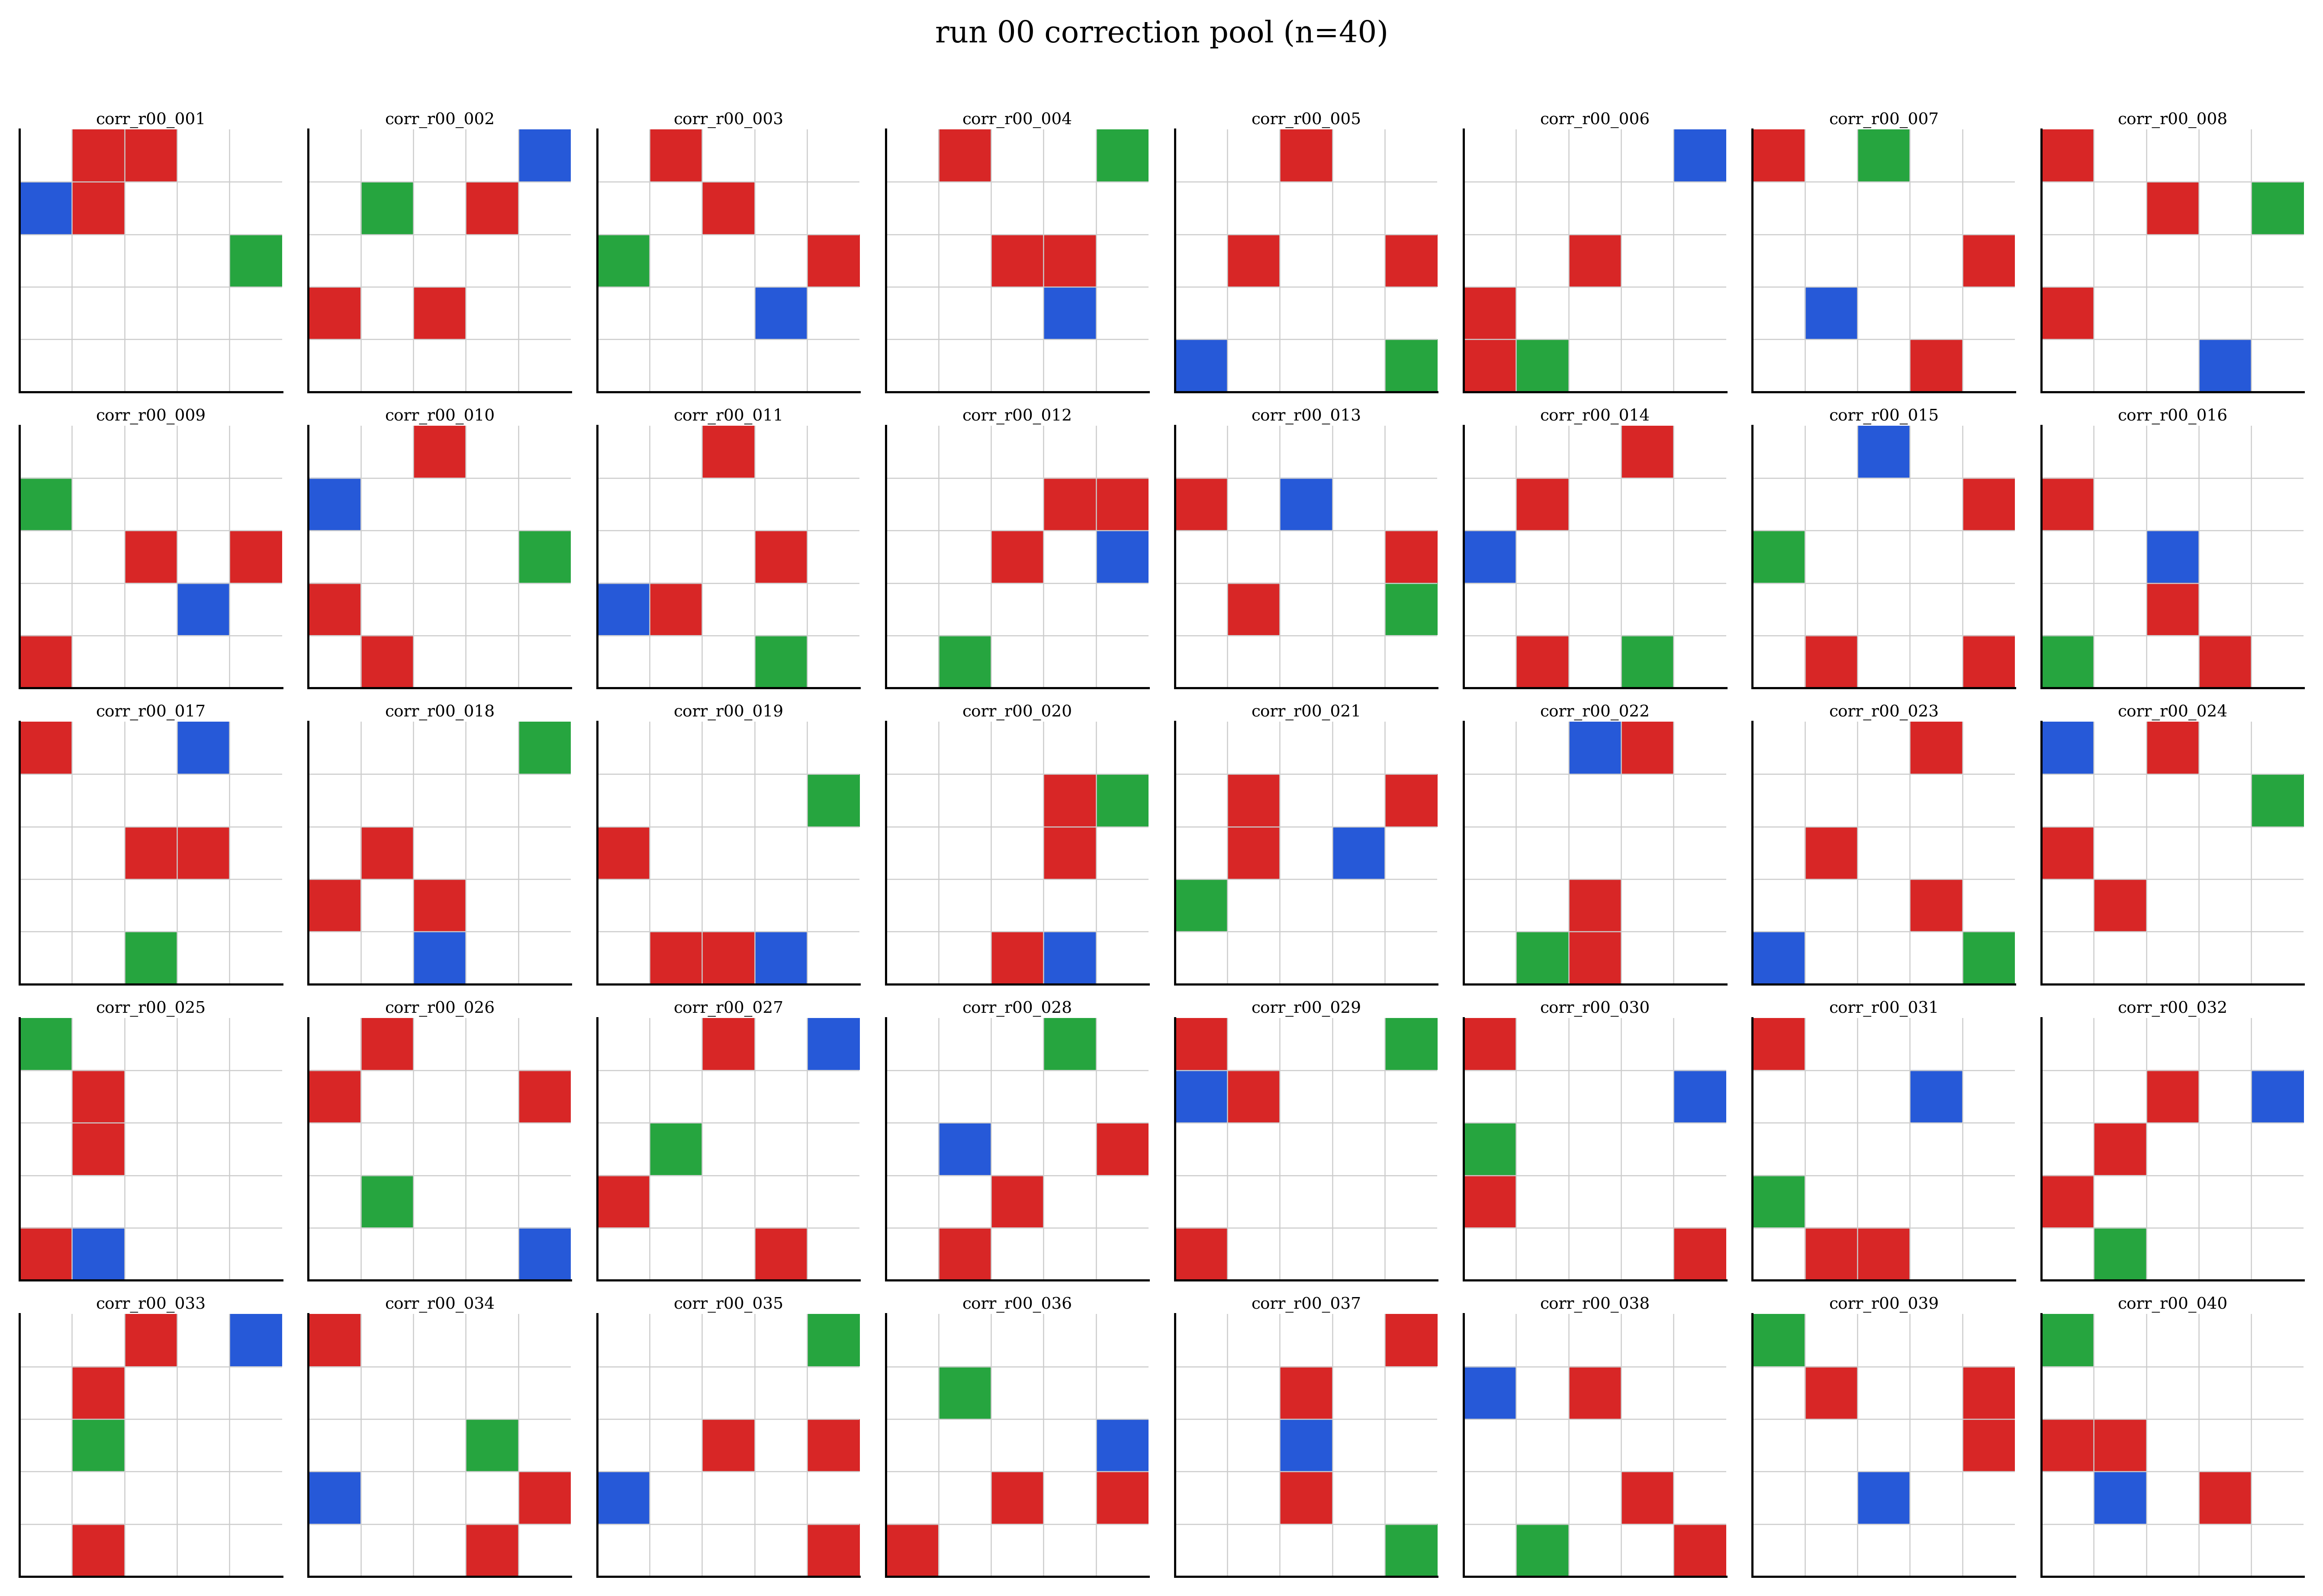


[run 00] BASELINE budget loop (init from swatch shared/init_*)
[13:42:43] [bo-budget] $ /home/s226137394/.conda/envs/maze/bin/python -u -m Equivariant_pathway.equivariant_CNN_hybrid.rollout_test --checkpoint /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_00/baseline_only/checkpoints/best_hybrid_policy.pth --layouts /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/heldout_layouts.yaml --out_dir /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_00/baseline_only/results/eval_round_000 --seed 0 --max_steps 60
[hybrid-rollout] 200 unique; running 200 eps
[hybrid-rollout] loaded /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_00/baseline_only/checkpoints/best_hybrid_policy.pth


/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=60 success=False
[hybrid-rollout] ep 2 (heldout_003): steps=4 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=60 success=False
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=60 success=False
[hybrid-rollout] ep 7 (heldout_008): steps=60 success=False
[hybrid-rollout] ep 8 (heldout_009): steps=2 success=False
[hybrid-rollout] ep 9 (heldout_010): steps=60 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=3 success=False
[hybrid-rollout] ep 12 (heldout_013): steps=60 success=False
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=1 success=False
[hybrid-rollout] ep 16 (heldout_017): steps=4 suc

/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=60 success=False
[hybrid-rollout] ep 2 (heldout_003): steps=60 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=60 success=False
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=60 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=5 success=True
[hybrid-rollout] ep 7 (heldout_008): steps=60 success=False
[hybrid-rollout] ep 8 (heldout_009): steps=2 success=False
[hybrid-rollout] ep 9 (heldout_010): steps=60 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=3 success=False
[hybrid-rollout] ep 12 (heldout_013): steps=60 success=False
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=1 success=False
[hybrid-rollout] ep 16 (heldout_017): steps=4 suc

...

[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=4 success=True
[hybrid-rollout] ep 2 (heldout_003): steps=8 success=True
[hybrid-rollout] ep 3 (heldout_004): steps=6 success=True
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=5 success=True
[hybrid-rollout] ep 7 (heldout_008): steps=4 success=True
[hybrid-rollout] ep 8 (heldout_009): steps=6 success=True
[hybrid-rollout] ep 9 (heldout_010): steps=60 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=4 success=True
[hybrid-rollout] ep 12 (heldout_013): steps=5 success=True
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=5 success=True
[hybrid-rollout] ep 16 (heldout_017): steps=4 success=True
[hyb

/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=4 success=True
[hybrid-rollout] ep 2 (heldout_003): steps=8 success=True
[hybrid-rollout] ep 3 (heldout_004): steps=6 success=True
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=5 success=True
[hybrid-rollout] ep 7 (heldout_008): steps=4 success=True
[hybrid-rollout] ep 8 (heldout_009): steps=6 success=True
[hybrid-rollout] ep 9 (heldout_010): steps=8 success=True
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=4 success=True
[hybrid-rollout] ep 12 (heldout_013): steps=5 success=True
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=5 success=True
[hybrid-rollout] ep 16 (heldout_017): steps=4 success=True
[hybri

/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=4 success=True
[hybrid-rollout] ep 2 (heldout_003): steps=8 success=True
[hybrid-rollout] ep 3 (heldout_004): steps=6 success=True
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=5 success=True
[hybrid-rollout] ep 7 (heldout_008): steps=4 success=True
[hybrid-rollout] ep 8 (heldout_009): steps=6 success=True
[hybrid-rollout] ep 9 (heldout_010): steps=8 success=True
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=4 success=True
[hybrid-rollout] ep 12 (heldout_013): steps=5 success=True
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=5 success=True
[hybrid-rollout] ep 16 (heldout_017): steps=4 success=True
[hybri

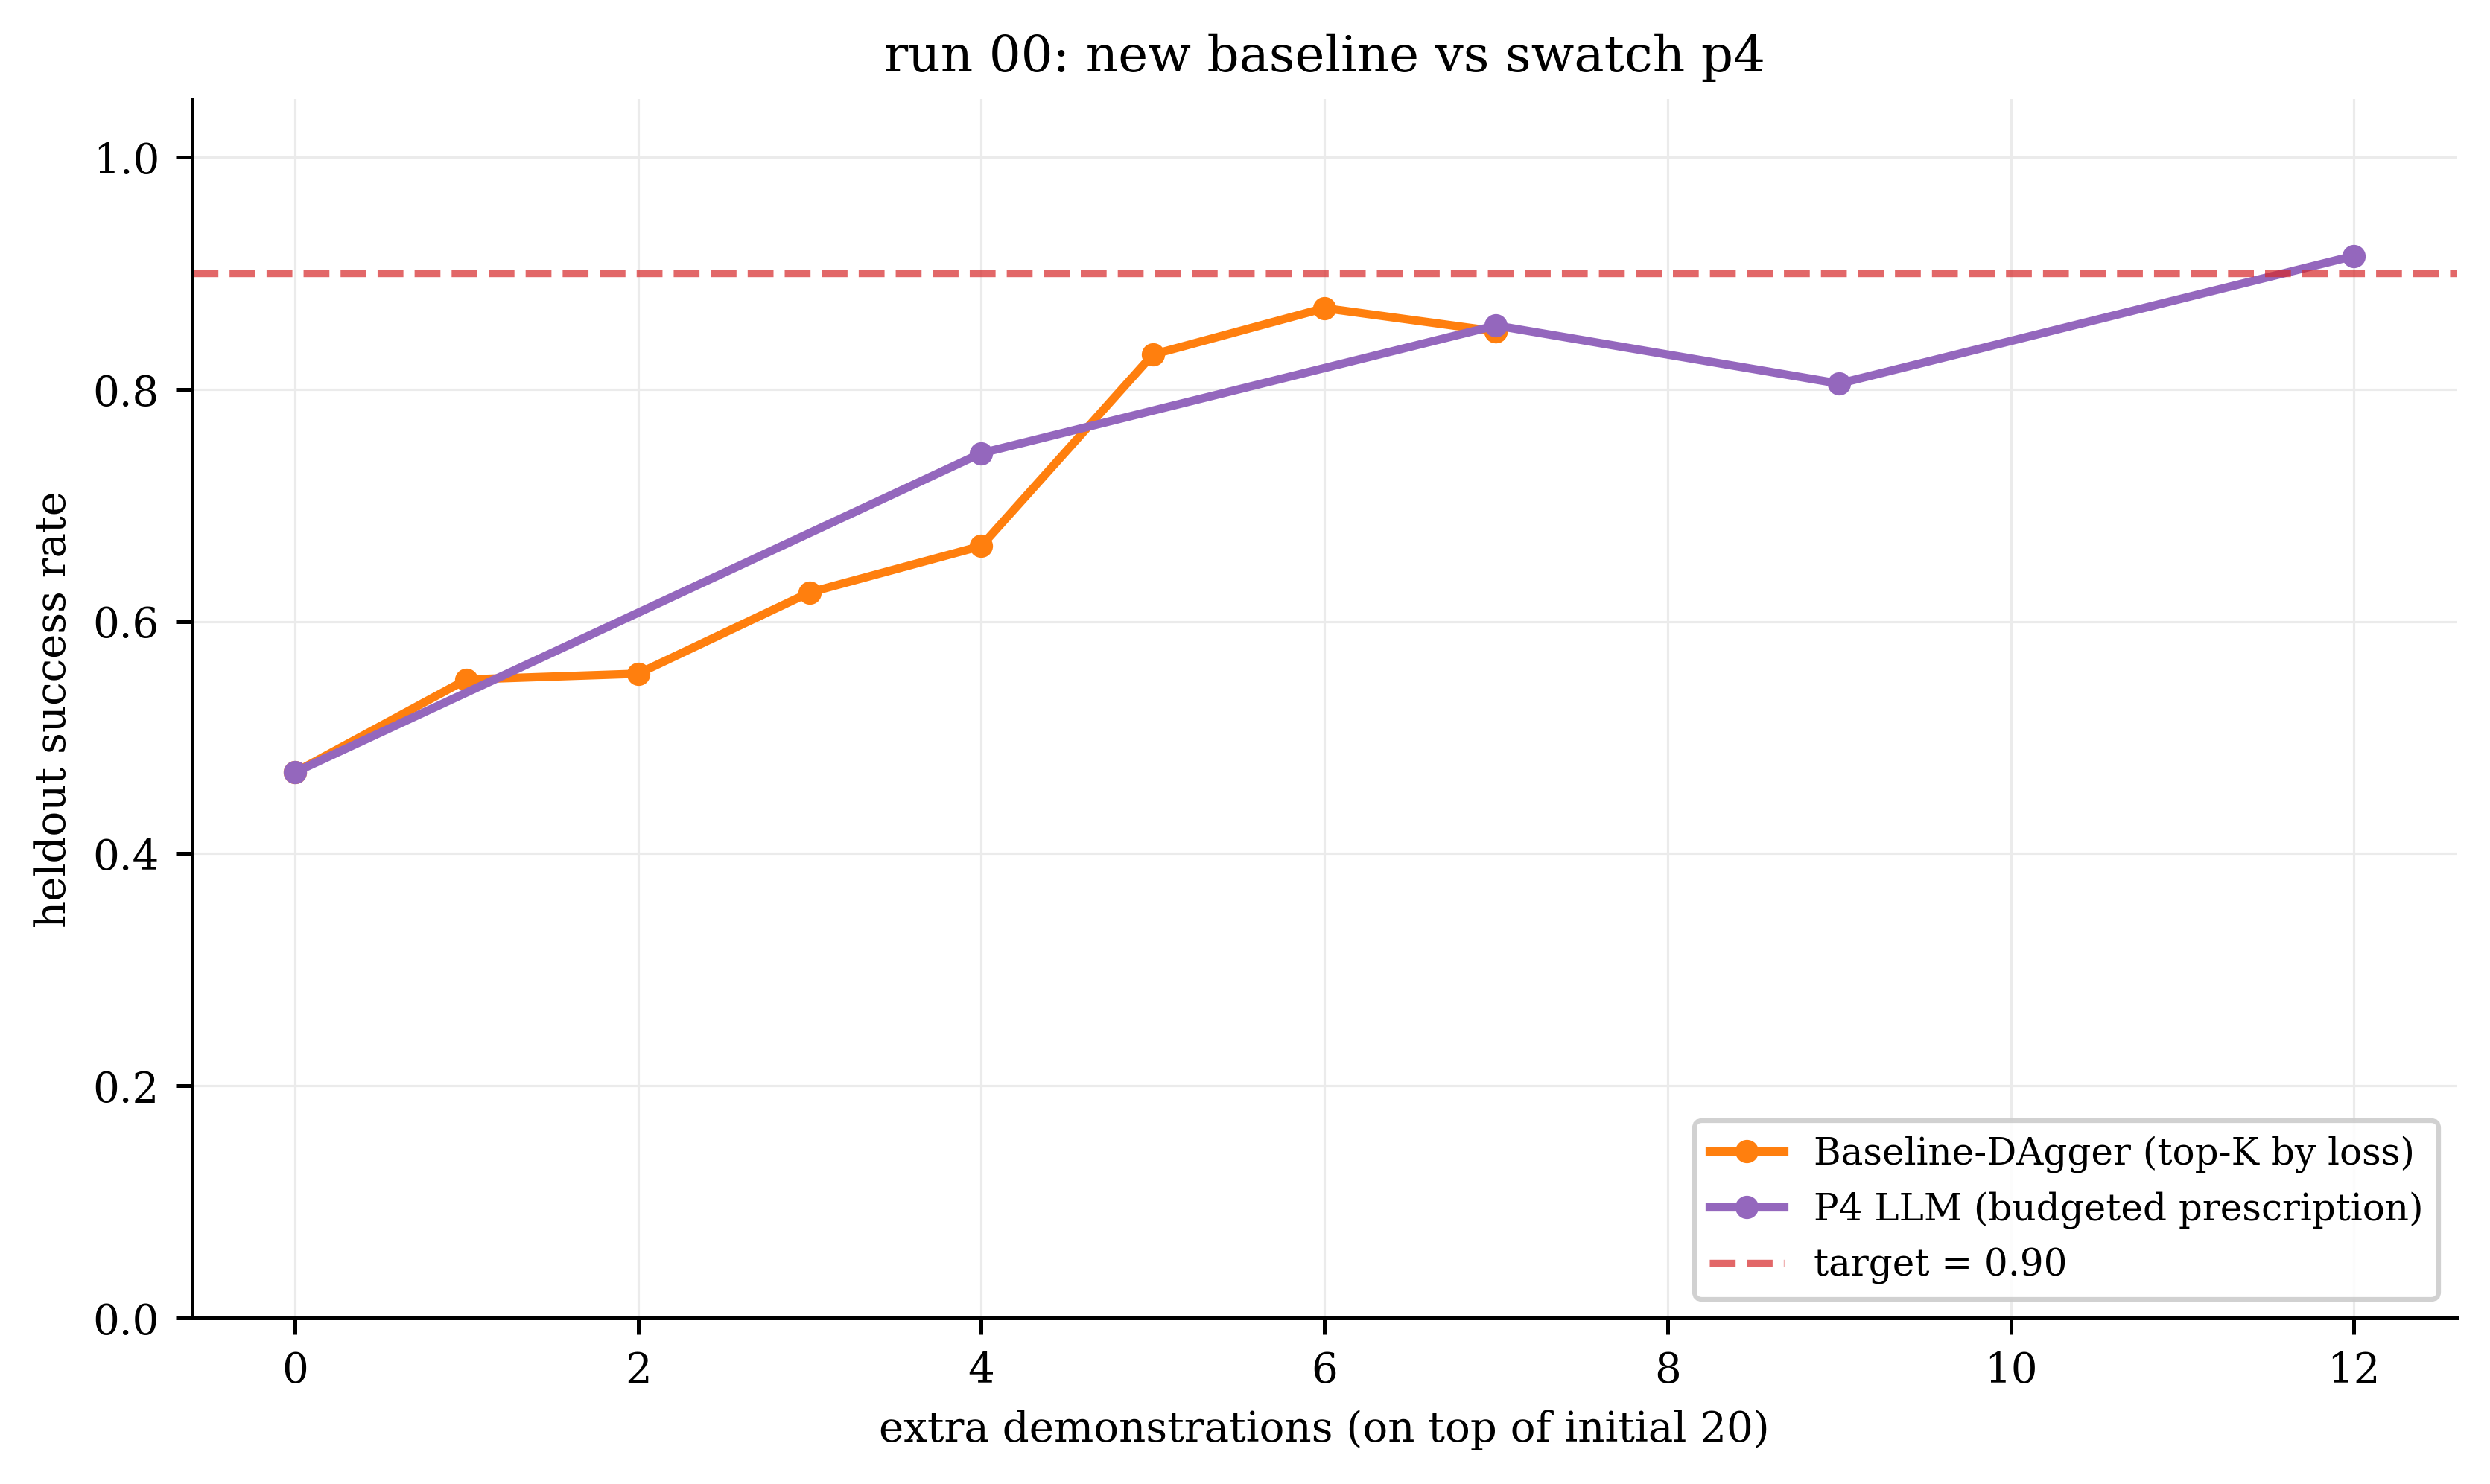

[nb] notebook_runs.json now has 1 run(s) -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/figures/baseline_nb_v3_runs.json

[run 00] DONE in 4569.8s -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_00


{'run_index': 0,
 'budget': 15,
 'target_sr': 0.9,
 'correction_yaml': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_00/shared/correction_layouts.yaml',
 'heldout_yaml': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/heldout_layouts.yaml',
 'training_yaml': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/training_layouts.yaml',
 'init_from': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/init_checkpoints',
 'swatch_pool_reused': True,
 'baseline_stopped_reason': 'no_new_demos'}

In [5]:
run_baseline_only(0)

### Run 1

[run 01] reused swatch correction pool -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs/run_01/shared/correction_layouts.yaml
[nb] wrote /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_01/correction_pool_layouts.png


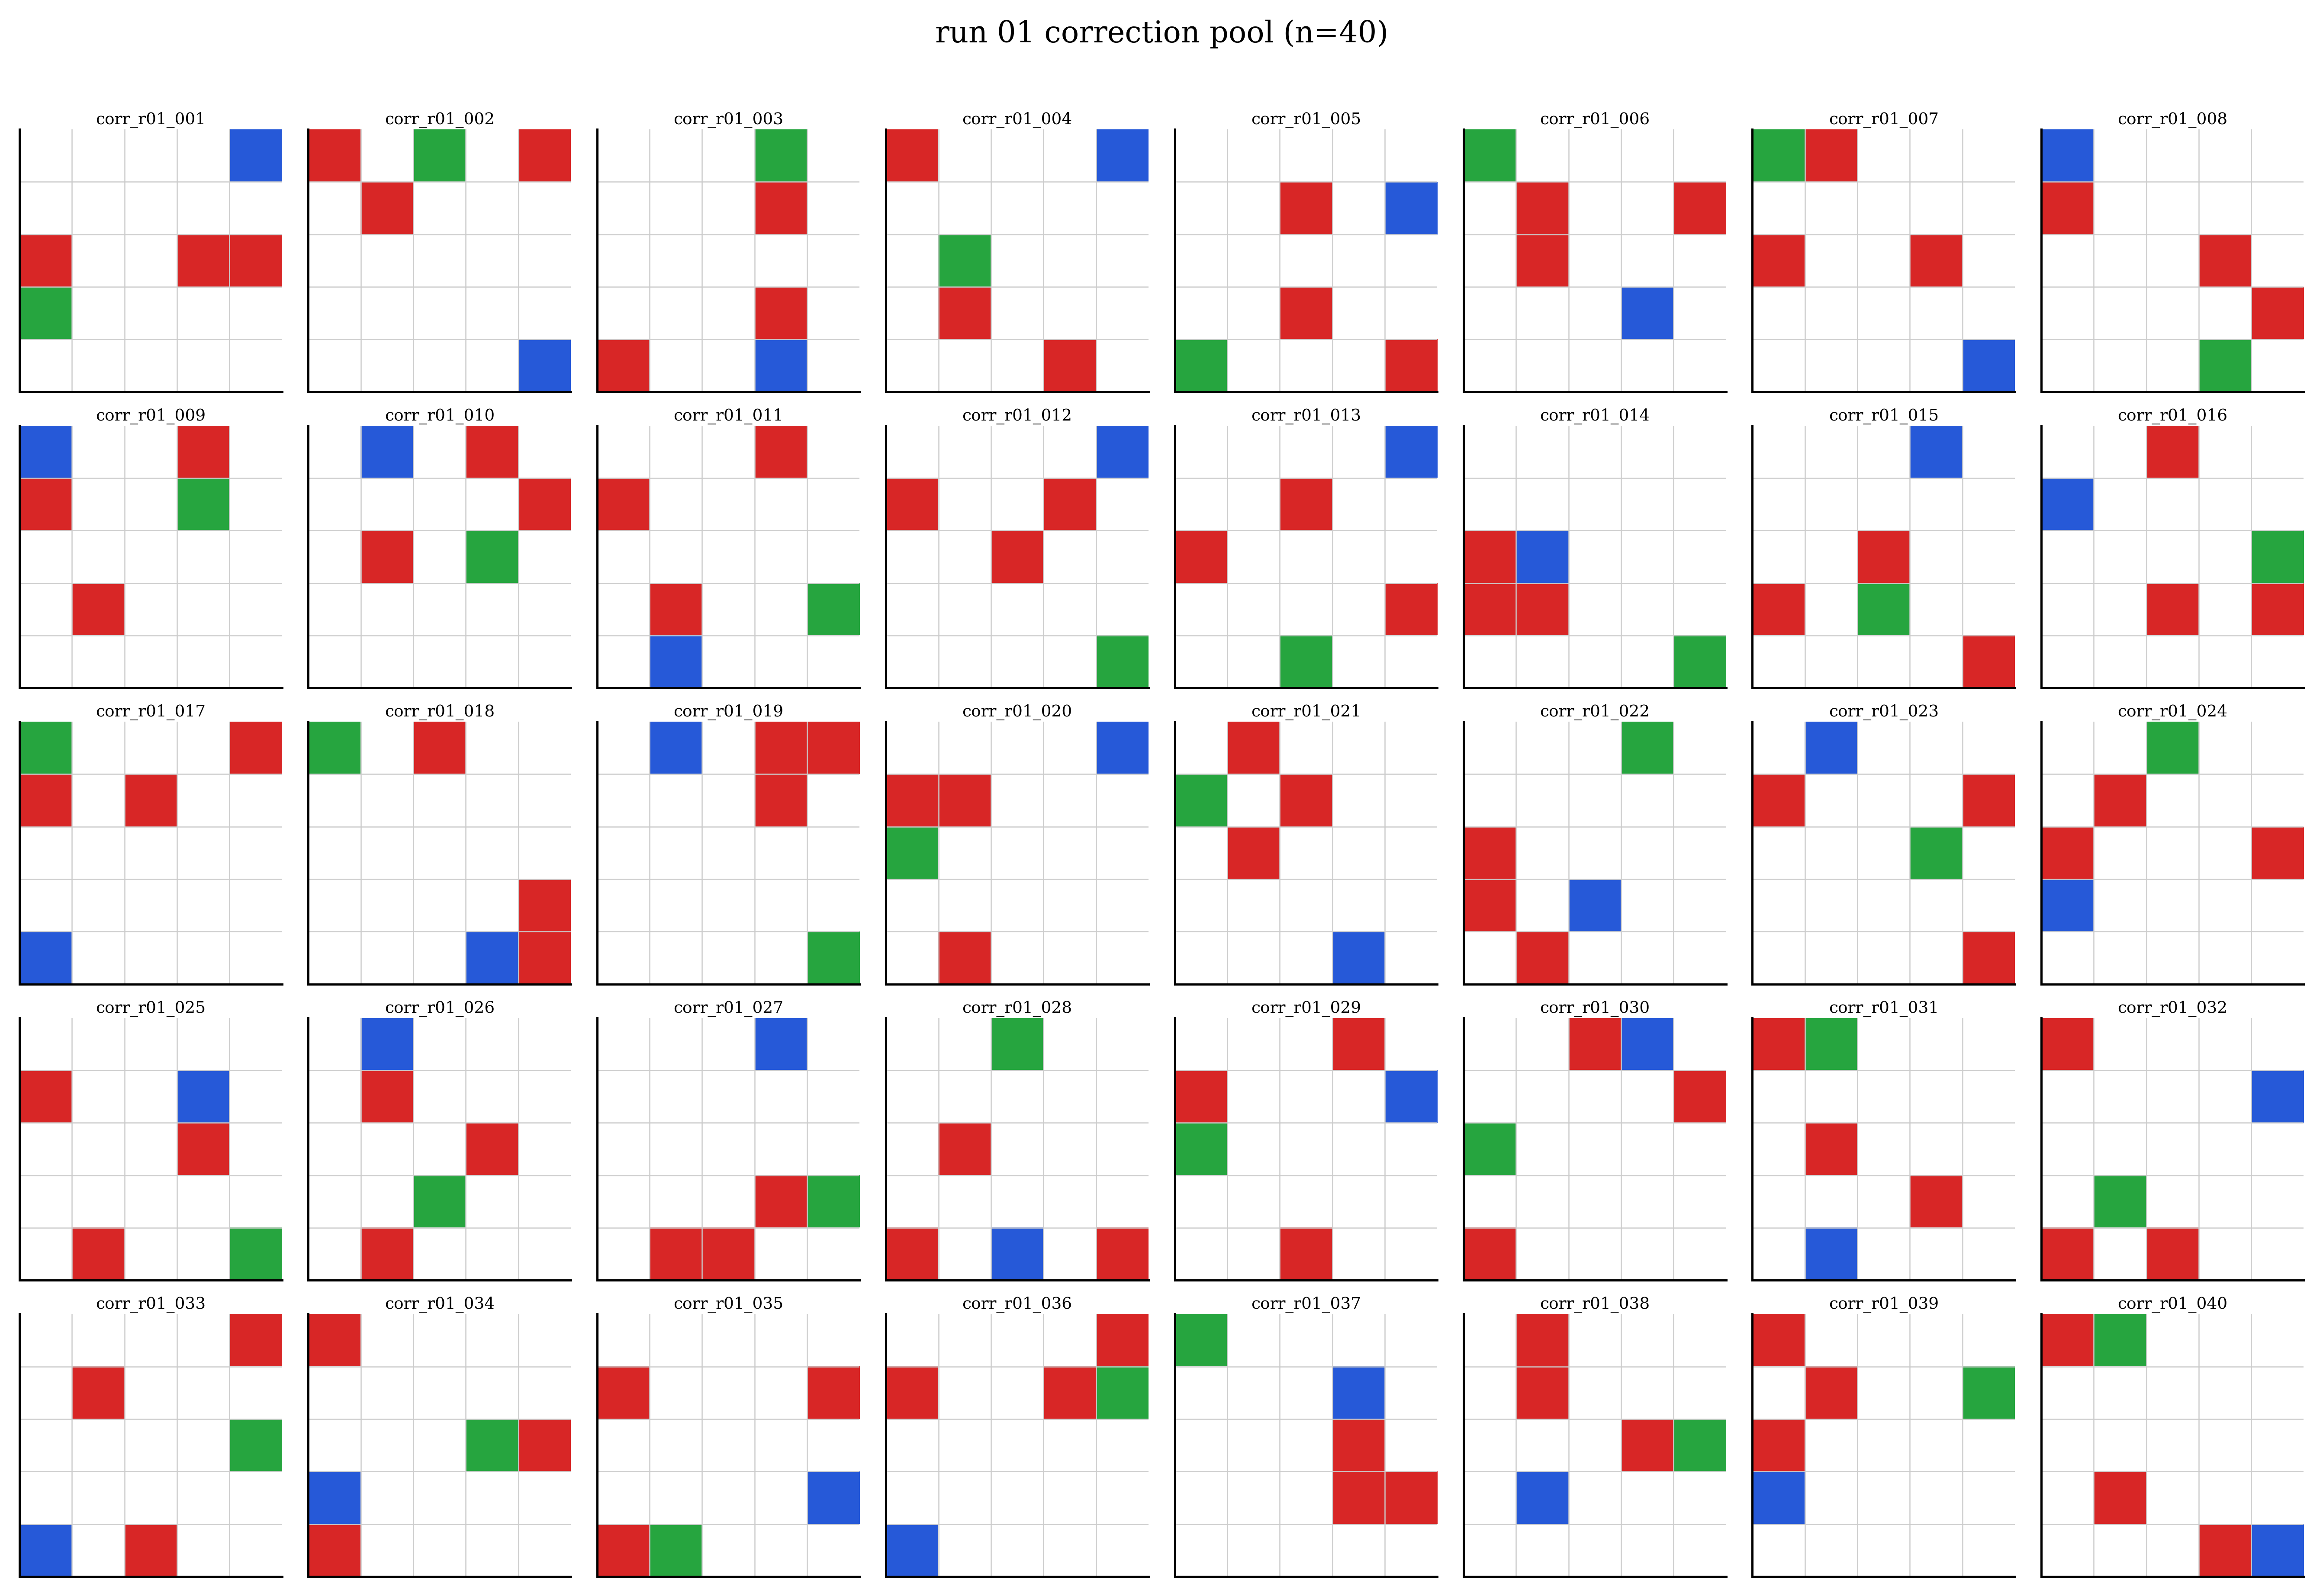


[run 01] BASELINE budget loop (init from swatch shared/init_*)
[14:59:02] [bo-budget] $ /home/s226137394/.conda/envs/maze/bin/python -u -m Equivariant_pathway.equivariant_CNN_hybrid.rollout_test --checkpoint /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_01/baseline_only/checkpoints/best_hybrid_policy.pth --layouts /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/heldout_layouts.yaml --out_dir /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_01/baseline_only/results/eval_round_000 --seed 0 --max_steps 60
[hybrid-rollout] 200 unique; running 200 eps
[hybrid-rollout] loaded /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_01/baseline_only/checkpoints/best_hybrid_policy.pth


/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=60 success=False
[hybrid-rollout] ep 2 (heldout_003): steps=4 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=60 success=False
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=60 success=False
[hybrid-rollout] ep 7 (heldout_008): steps=60 success=False
[hybrid-rollout] ep 8 (heldout_009): steps=2 success=False
[hybrid-rollout] ep 9 (heldout_010): steps=60 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=3 success=False
[hybrid-rollout] ep 12 (heldout_013): steps=60 success=False
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=1 success=False
[hybrid-rollout] ep 16 (heldout_017): steps=4 suc

/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=10 success=True
[hybrid-rollout] ep 2 (heldout_003): steps=60 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=60 success=False
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=3 success=False
[hybrid-rollout] ep 7 (heldout_008): steps=60 success=False
[hybrid-rollout] ep 8 (heldout_009): steps=2 success=False
[hybrid-rollout] ep 9 (heldout_010): steps=60 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=3 success=False
[hybrid-rollout] ep 12 (heldout_013): steps=5 success=True
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=1 success=False
[hybrid-rollout] ep 16 (heldout_017): steps=4 succes

...

[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=60 success=False
[hybrid-rollout] ep 2 (heldout_003): steps=4 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=6 success=True
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=5 success=True
[hybrid-rollout] ep 7 (heldout_008): steps=60 success=False
[hybrid-rollout] ep 8 (heldout_009): steps=2 success=False
[hybrid-rollout] ep 9 (heldout_010): steps=60 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=6 success=True
[hybrid-rollout] ep 12 (heldout_013): steps=5 success=True
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=60 success=False
[hybrid-rollout] ep 16 (heldout_017): steps=4 success=T

/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=4 success=True
[hybrid-rollout] ep 2 (heldout_003): steps=60 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=6 success=True
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=6 success=True
[hybrid-rollout] ep 6 (heldout_007): steps=5 success=True
[hybrid-rollout] ep 7 (heldout_008): steps=4 success=True
[hybrid-rollout] ep 8 (heldout_009): steps=6 success=True
[hybrid-rollout] ep 9 (heldout_010): steps=6 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=4 success=True
[hybrid-rollout] ep 12 (heldout_013): steps=5 success=True
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=5 success=True
[hybrid-rollout] ep 16 (heldout_017): steps=4 success=True
[hyb

/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=4 success=True
[hybrid-rollout] ep 2 (heldout_003): steps=60 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=6 success=True
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=6 success=True
[hybrid-rollout] ep 6 (heldout_007): steps=5 success=True
[hybrid-rollout] ep 7 (heldout_008): steps=4 success=True
[hybrid-rollout] ep 8 (heldout_009): steps=6 success=True
[hybrid-rollout] ep 9 (heldout_010): steps=6 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=4 success=True
[hybrid-rollout] ep 12 (heldout_013): steps=5 success=True
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=5 success=True
[hybrid-rollout] ep 16 (heldout_017): steps=4 success=True
[hyb

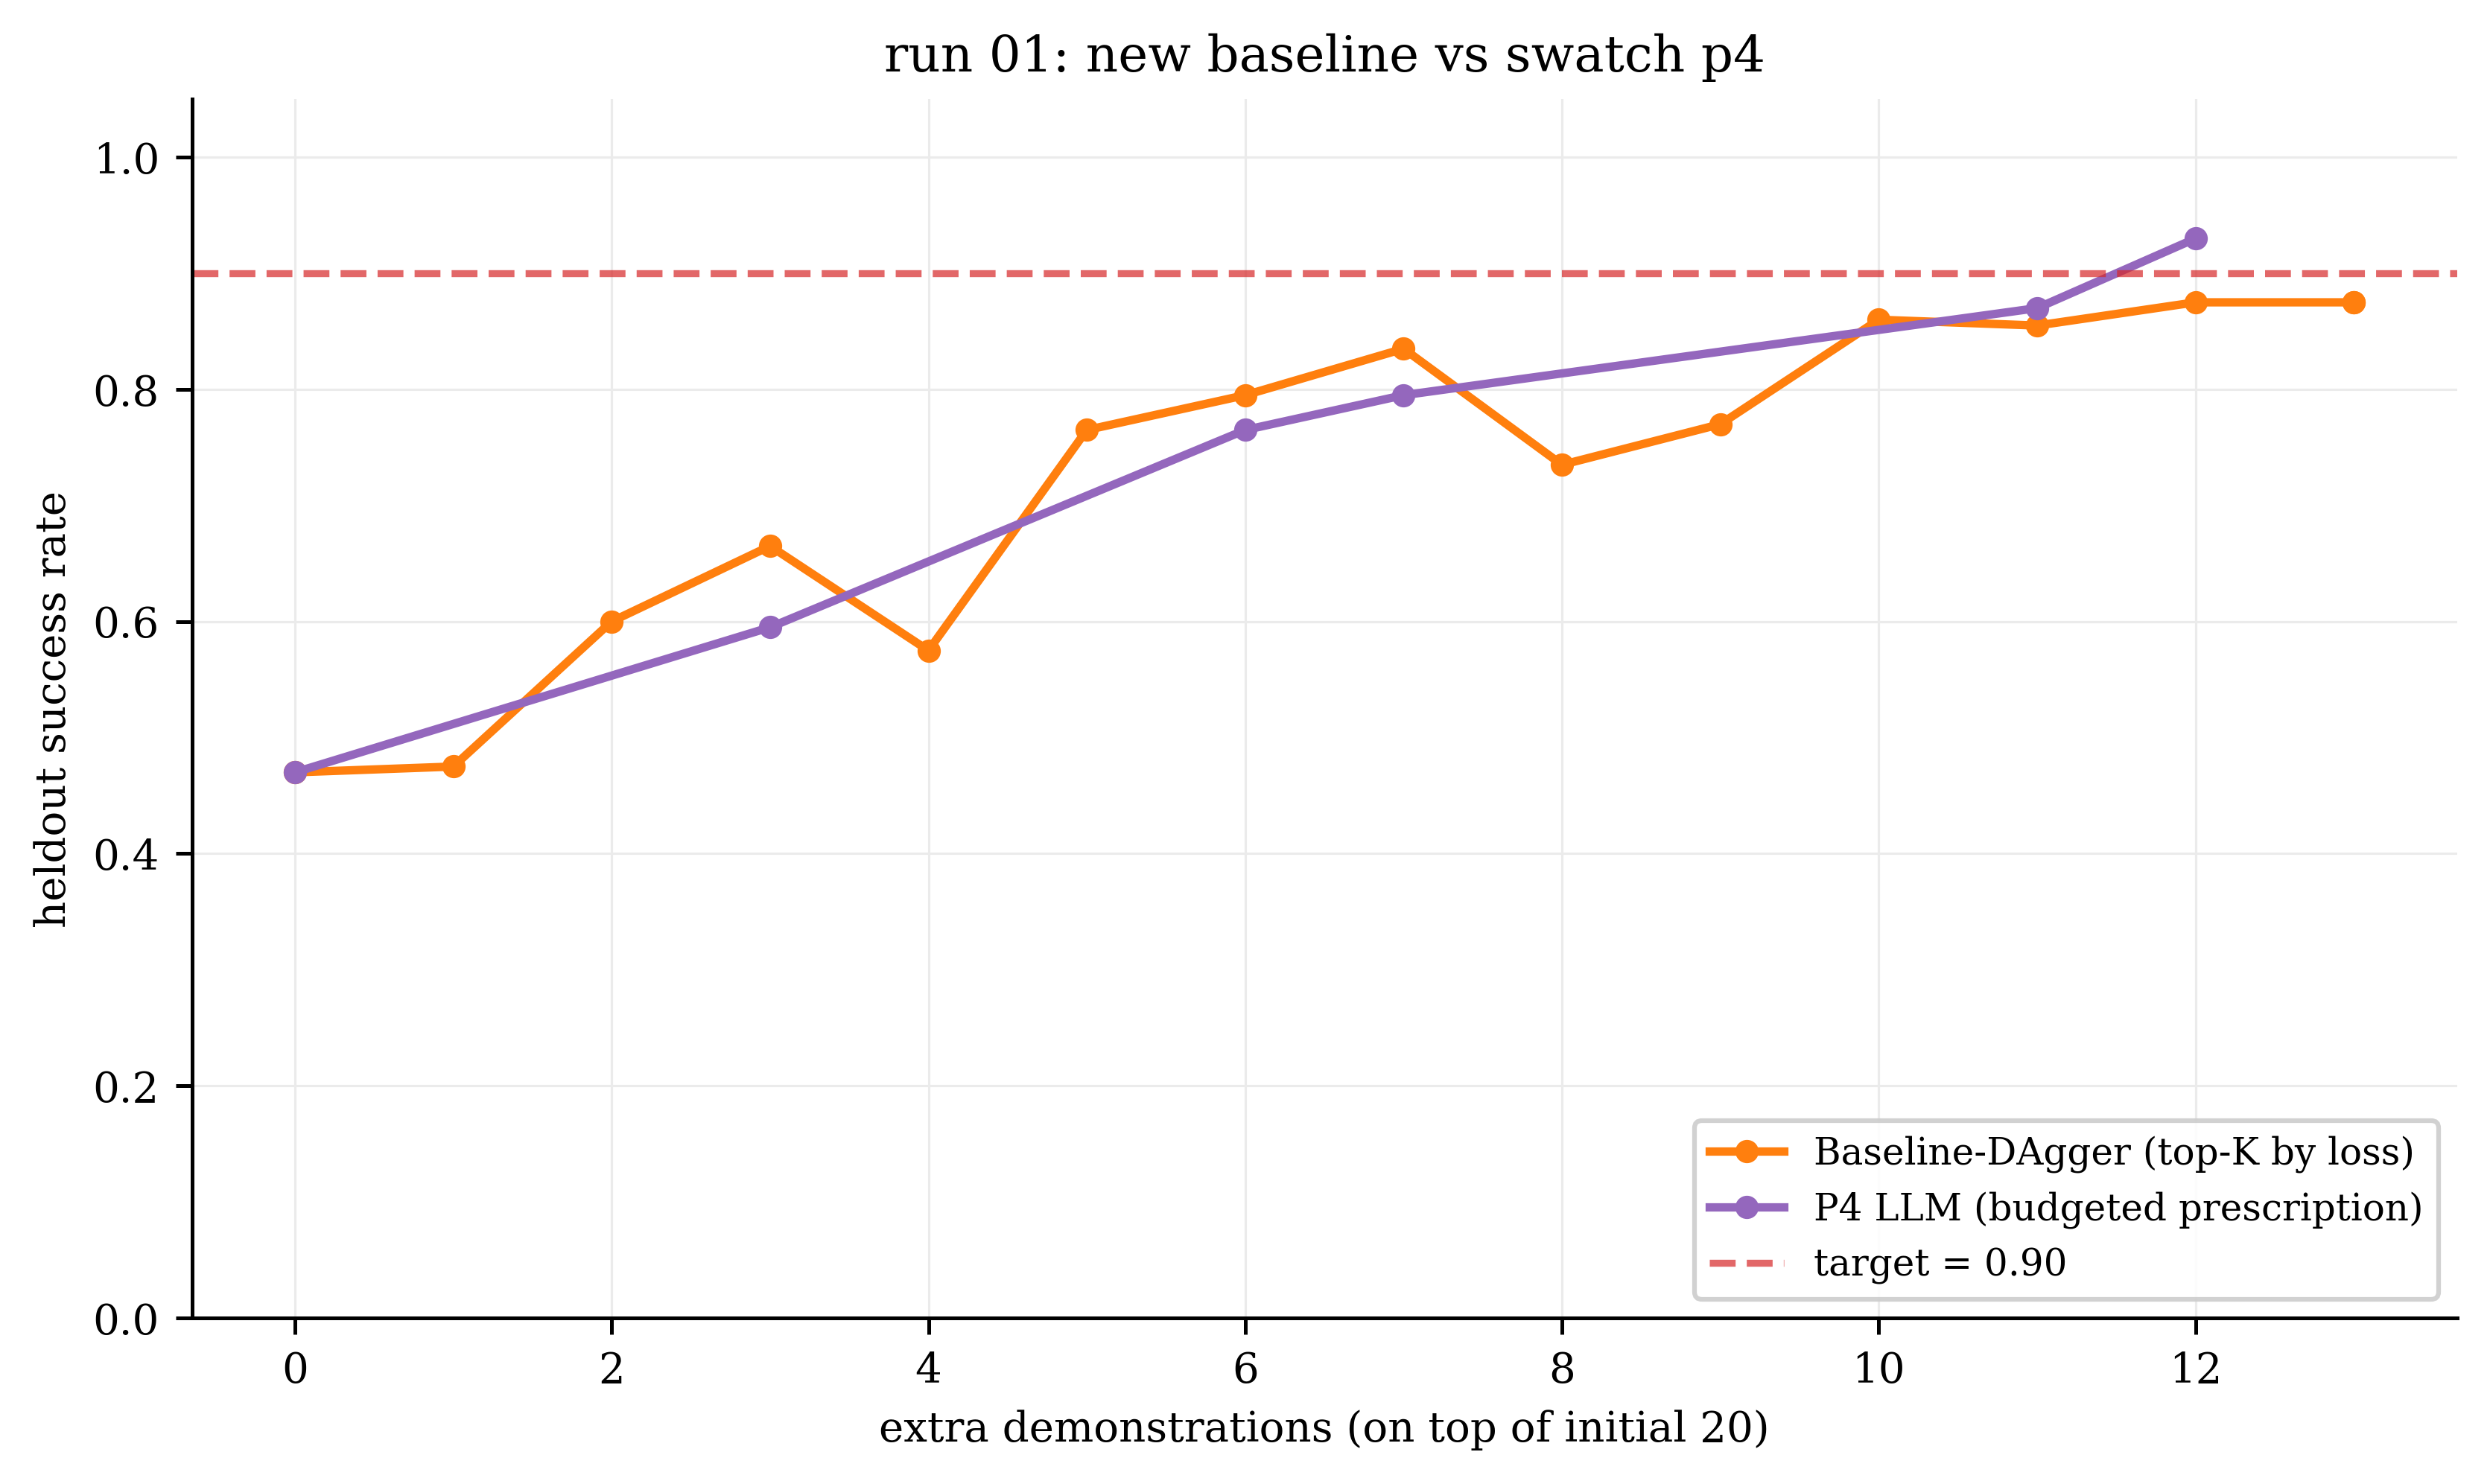

[nb] notebook_runs.json now has 2 run(s) -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/figures/baseline_nb_v3_runs.json

[run 01] DONE in 8726.0s -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_01


{'run_index': 1,
 'budget': 15,
 'target_sr': 0.9,
 'correction_yaml': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_01/shared/correction_layouts.yaml',
 'heldout_yaml': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/heldout_layouts.yaml',
 'training_yaml': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/training_layouts.yaml',
 'init_from': '/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/init_checkpoints',
 'swatch_pool_reused': True,
 'baseline_stopped_reason': 'no_new_demos'}

In [6]:
run_baseline_only(1)

### Run 2

In [ ]:
run_baseline_only(2)

[run 03] reused swatch correction pool -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs/run_03/shared/correction_layouts.yaml
[nb] wrote /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_03/correction_pool_layouts.png


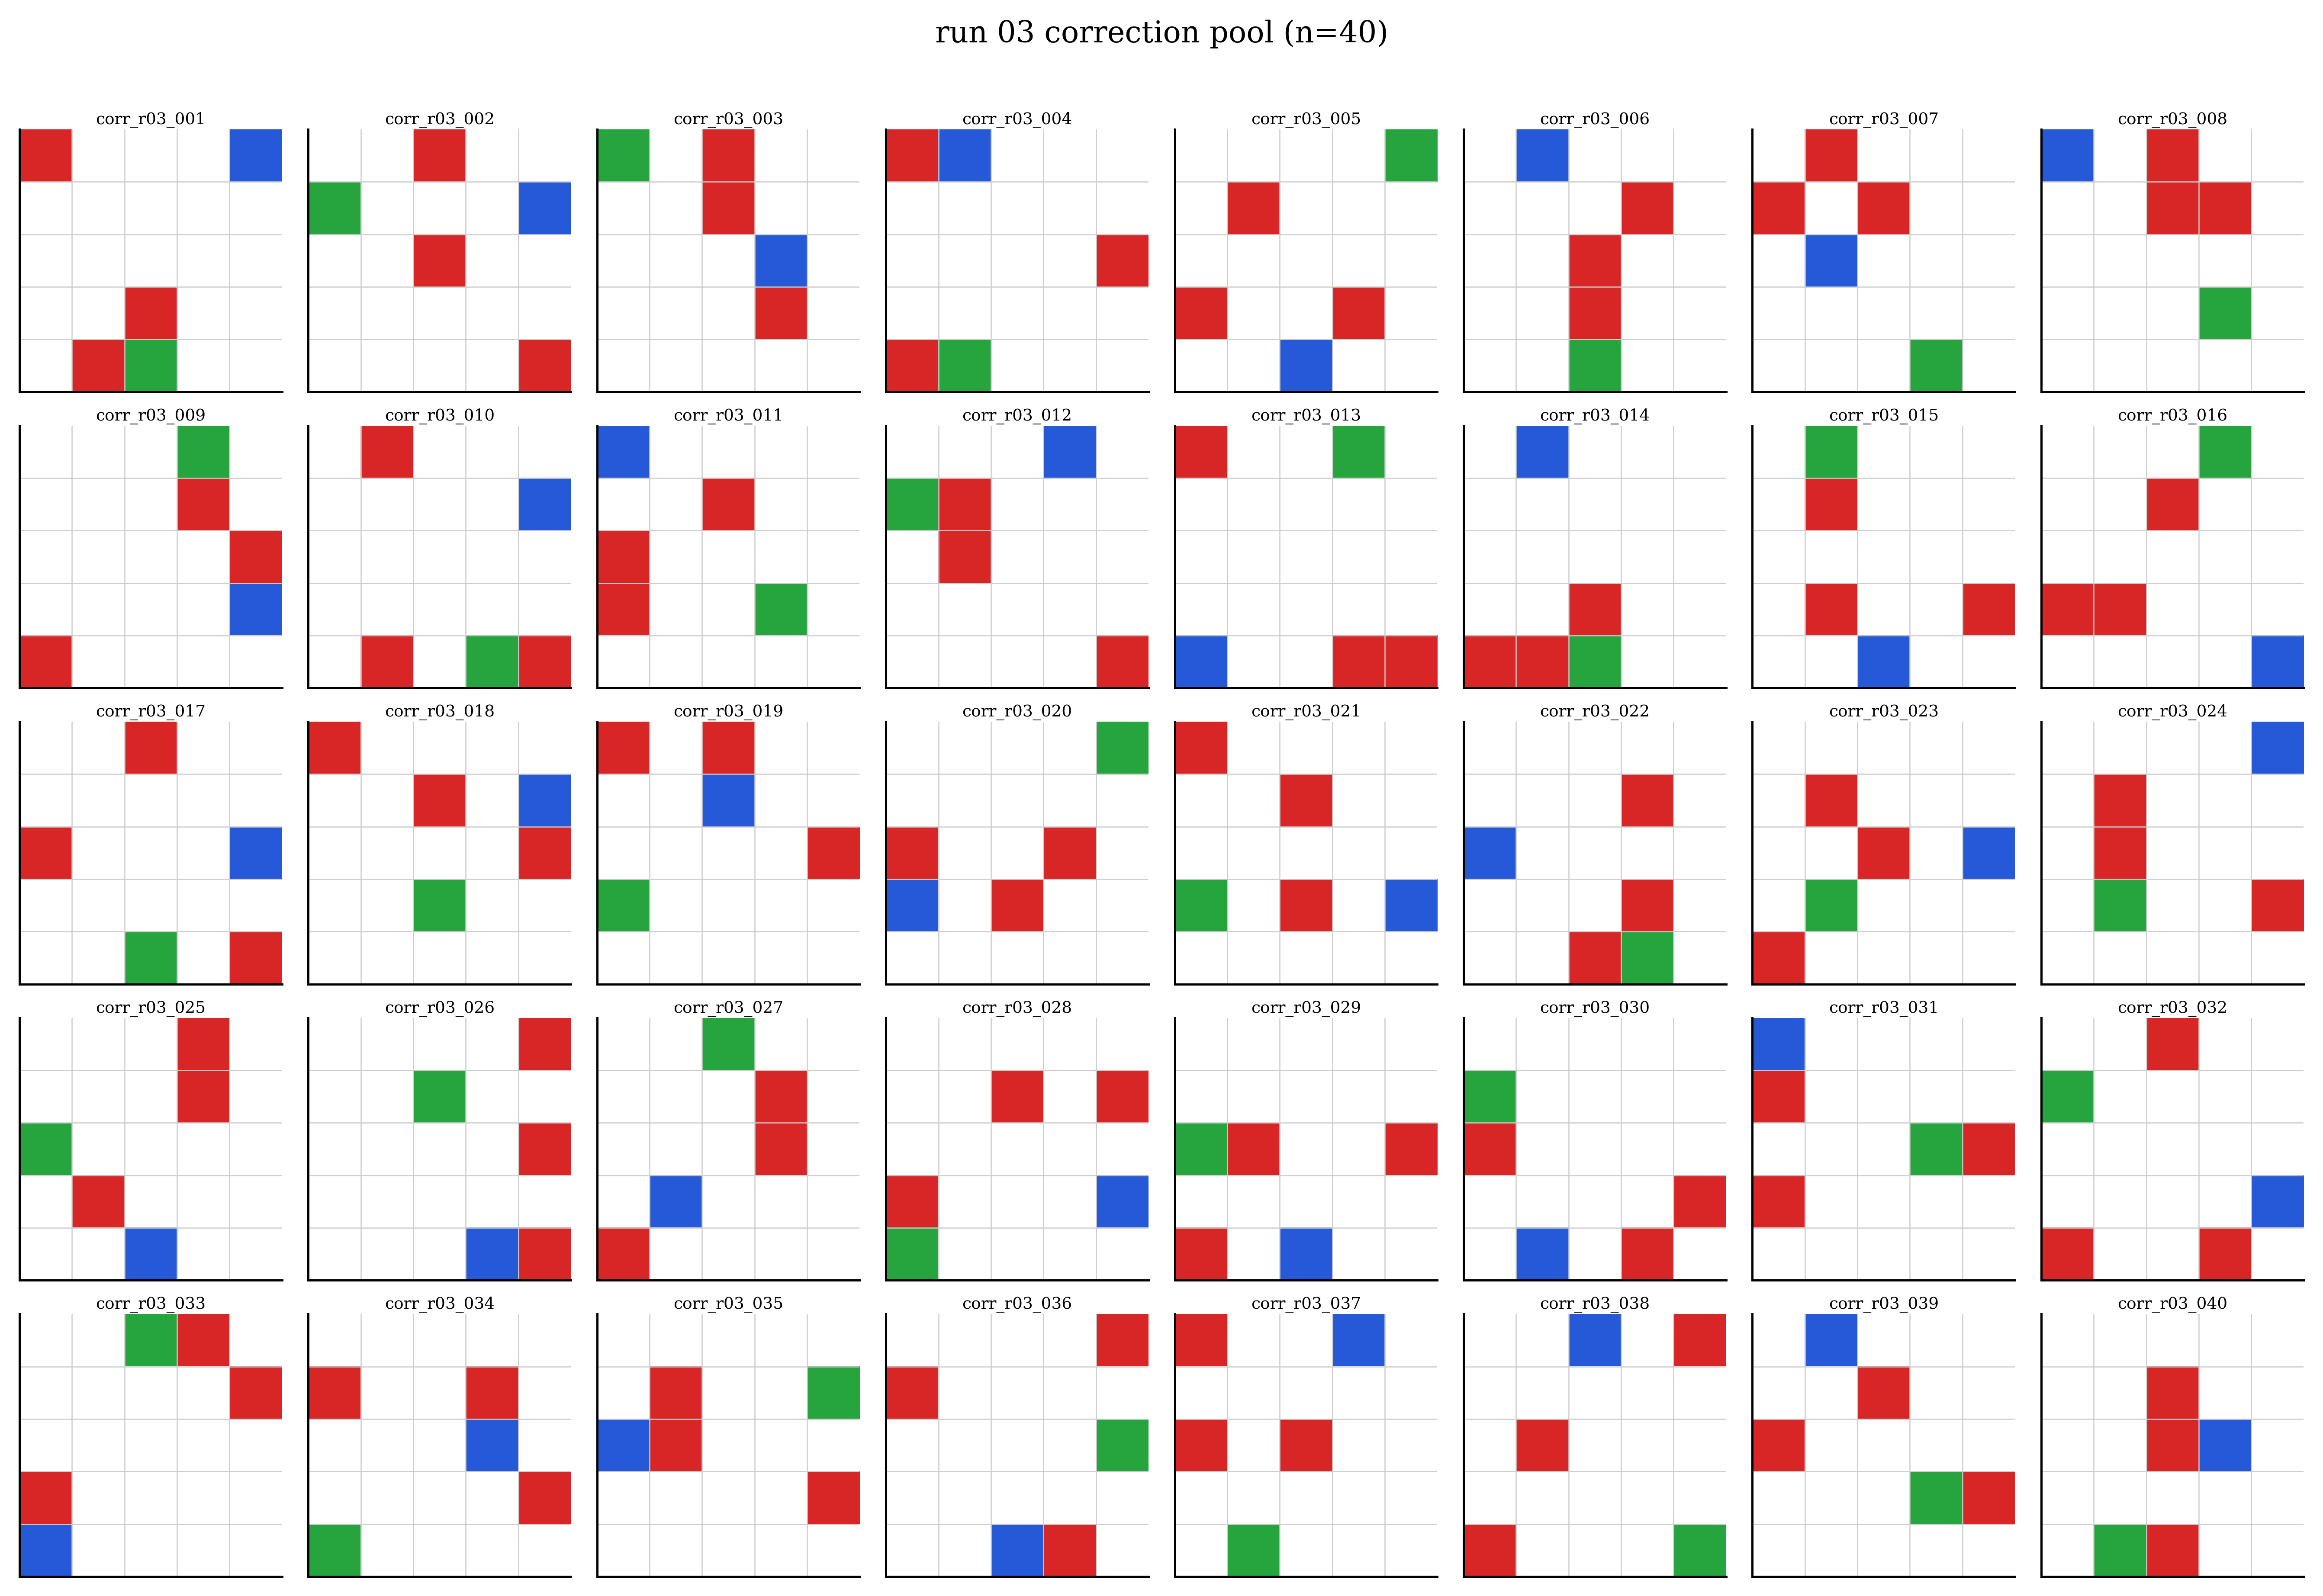


[run 03] BASELINE budget loop (init from swatch shared/init_*)
[17:25:13] [bo-budget] $ /home/s226137394/.conda/envs/maze/bin/python -u -m Equivariant_pathway.equivariant_CNN_hybrid.rollout_test --checkpoint /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_03/baseline_only/checkpoints/best_hybrid_policy.pth --layouts /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/heldout_layouts.yaml --out_dir /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_03/baseline_only/results/eval_round_000 --seed 0 --max_steps 60
[hybrid-rollout] 200 unique; running 200 eps
[hybrid-rollout] loaded /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_baseline_nb_v3/run_03/baseline_only/checkpoints/best_hybrid_policy.pth


/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (heldout_001): steps=5 success=True
[hybrid-rollout] ep 1 (heldout_002): steps=60 success=False
[hybrid-rollout] ep 2 (heldout_003): steps=4 success=False
[hybrid-rollout] ep 3 (heldout_004): steps=60 success=False
[hybrid-rollout] ep 4 (heldout_005): steps=5 success=True
[hybrid-rollout] ep 5 (heldout_006): steps=3 success=False
[hybrid-rollout] ep 6 (heldout_007): steps=60 success=False
[hybrid-rollout] ep 7 (heldout_008): steps=60 success=False
[hybrid-rollout] ep 8 (heldout_009): steps=2 success=False
[hybrid-rollout] ep 9 (heldout_010): steps=60 success=False
[hybrid-rollout] ep 10 (heldout_011): steps=4 success=True
[hybrid-rollout] ep 11 (heldout_012): steps=3 success=False
[hybrid-rollout] ep 12 (heldout_013): steps=60 success=False
[hybrid-rollout] ep 13 (heldout_014): steps=5 success=True
[hybrid-rollout] ep 14 (heldout_015): steps=4 success=True
[hybrid-rollout] ep 15 (heldout_016): steps=1 success=False
[hybrid-rollout] ep 16 (heldout_017): steps=4 suc

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/rollout_test.py", line 306, in <module>
    main()
  File "/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/rollout_test.py", line 250, in main
    gif_path = _save_gif(ed["steps"], episode_dir, args.gif_duration_ms)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/rollout_test.py", line 116, in _save_gif
    frames[0].save(str(gif_path), save_all=True, append_images=frames[1:],
  File "/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/PIL/Image.py", line 2431, in save
    save_handler(self, fp, filename)
  File "/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/PIL/GifImagePlugin.py", line 658, in _save_all
    _save(i

In [ ]:
run_baseline_only(3)

In [ ]:
run_baseline_only(4)

In [ ]:
run_baseline_only(5)

In [ ]:
run_baseline_only(6)

In [ ]:
run_baseline_only(7)

In [ ]:
run_baseline_only(8)

In [ ]:
run_baseline_only(9)

## 6. REPLOT — new baseline vs existing swatch P4 *(no re-run)*

Reads this notebook's baseline from `baseline_nb_runs.json` and the P4 mean±std straight from the swatch `runs/run_*/p4_only/`.

In [ ]:
# ----------------------- styling knobs (edit freely) -----------------------
BASELINE_COLOR   = aggregate_chart.METHOD_COLORS["baseline_only"]  # tab:orange
P4_COLOR         = aggregate_chart.METHOD_COLORS["p4_only"]        # tab:purple
MEAN_LINEWIDTH   = 1.8
PERRUN_LINEWIDTH = 0.8
PERRUN_ALPHA     = 0.18
BAND_ALPHA       = 0.18
SHOW_PERRUN      = True       # faint per-run baseline curves
FIGSIZE          = (7.5, 4.5)
TITLE            = None       # e.g. "Re-run baseline vs swatch P4"
# ---------------------------------------------------------------------------

doc = nb_helpers.load_notebook_json(BASELINE_JSON)
bruns = doc.get("runs", []) or []
budget = int(doc.get("budget") or globals().get("BUDGET", 15))
target = float(doc.get("target_sr") or globals().get("TARGET_SR", 0.90))
x_grid = np.arange(0, budget + 1, dtype=int)

# Baseline rows from THIS notebook's JSON.
bo_rows = [r["baseline_only"] for r in bruns
           if r.get("baseline_only") and r["baseline_only"].get("xs")]
# P4 rows straight from the swatch runs/.
p4_rows = []
for cp in sorted(SWATCH_RUNS_DIR.glob("run_*/p4_only/results/learning_curve.json")):
    curve = aggregate_chart._load_curve(cp)
    xs, ys = aggregate_chart._curve_xy((curve or {}).get("history", []) or [])
    if xs:
        p4_rows.append({"xs": xs, "ys": ys})

print(f"baseline runs (this nb): {len(bo_rows)}  |  swatch p4 runs: {len(p4_rows)}")
if nb_helpers.STYLE_PATH.exists():
    plt.style.use(str(nb_helpers.STYLE_PATH))

fig, ax = plt.subplots(figsize=FIGSIZE)
for rows, color, label, show_pr in (
    (bo_rows, BASELINE_COLOR, aggregate_chart.METHOD_LABELS["baseline_only"], SHOW_PERRUN),
    (p4_rows, P4_COLOR,       aggregate_chart.METHOD_LABELS["p4_only"],       False),
):
    if not rows:
        continue
    Y = np.vstack([aggregate_chart._sample_hold(r["xs"], r["ys"], x_grid)
                   for r in rows])
    if show_pr:
        for y in Y:
            ax.plot(x_grid, y, color=color, alpha=PERRUN_ALPHA,
                    linewidth=PERRUN_LINEWIDTH)
    mean = Y.mean(axis=0)
    std = Y.std(axis=0, ddof=0)
    ax.plot(x_grid, mean, color=color, marker="o", markersize=4,
            linewidth=MEAN_LINEWIDTH, label=f"{label}  (mean, n={Y.shape[0]})")
    ax.fill_between(x_grid, mean - std, mean + std, color=color,
                    alpha=BAND_ALPHA, linewidth=0)

ax.axhline(target, ls="--", color="tab:red", alpha=0.7,
           label=f"target = {target:.2f}")
ax.set_xlabel("extra demonstrations (on top of initial set)")
ax.set_ylabel("heldout success rate")
ax.set_xlim(0, budget)
ax.set_ylim(0, 1.05)
if TITLE:
    ax.set_title(TITLE)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.tight_layout()
_out = COMPARE_ROOT / "figures" / "baseline_nb_v3_vs_swatch_p4.png"
fig.savefig(_out)
print("wrote", _out)
plt.show()

In [ ]:
# ============================================================================
# EXTRA 1/4 - drop run_02, compare only the OTHER 9 runs (baseline + P4).
#
# SELF-CONTAINED: re-derives everything from on-disk artifacts and imports
# only the lightweight `aggregate_chart` (no torch). You do NOT need to
# re-run cells 1-24. Run THIS cell first, then the next three.
# ============================================================================
import sys, re, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

_REPO_ROOT = Path("/vast/s226137394/DmN/DmNfull")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
except Exception:
    pass

EXCLUDE_RUNS = {2}                       # run_02 dropped for BOTH methods

_COMPARE_ROOT  = Path(aggregate_chart.__file__).resolve().parent
_SWATCH_RUNS   = _COMPARE_ROOT / "runs"              # P4 source (swatch)
_BASELINE_RUNS = _COMPARE_ROOT / "runs_baseline_nb_v3"  # V3 fine-tune runs
_BASELINE_JSON = _COMPARE_ROOT / "figures" / "baseline_nb_v3_runs.json"
_FIG_DIR       = _COMPARE_ROOT / "figures"
_STYLE         = str(_COMPARE_ROOT / "paper.mplstyle")


def _use_style():
    try:
        if Path(_STYLE).exists():
            plt.style.use(_STYLE)
    except Exception:
        pass


try:
    _doc = json.loads(_BASELINE_JSON.read_text())
except Exception:
    _doc = {}
BUDGET = int(_doc.get("budget") or 15)
TARGET = float(_doc.get("target_sr") or 0.90)
XGRID  = np.arange(0, BUDGET + 1, dtype=int)
_RUN_RE = re.compile(r"run_(\d+)")


def _load_method(base, method):
    """{run_idx: (xs, ys)} from <base>/run_NN/<method>/results/learning_curve.json"""
    out = {}
    for cp in sorted(base.glob(f"run_*/{method}/results/learning_curve.json")):
        m = _RUN_RE.search(cp.parts[-4])
        if not m:
            continue
        curve = aggregate_chart._load_curve(cp)
        xs, ys = aggregate_chart._curve_xy((curve or {}).get("history", []) or [])
        if xs:
            out[int(m.group(1))] = (xs, ys)
    return out


_BO = _load_method(_BASELINE_RUNS, "baseline_only")
_P4 = _load_method(_SWATCH_RUNS,   "p4_only")
COMMON9 = sorted((set(_BO) & set(_P4)) - EXCLUDE_RUNS)


def _final_sr(xy):    # true terminal heldout SR (last logged row)
    return float(xy[1][-1])


def _final_extra(xy):
    return int(xy[0][-1])


YB = np.vstack([aggregate_chart._sample_hold(*_BO[i], XGRID) for i in COMMON9])
YP = np.vstack([aggregate_chart._sample_hold(*_P4[i], XGRID) for i in COMMON9])

NINE = {
    "common": COMMON9, "xgrid": XGRID, "budget": BUDGET, "target": TARGET,
    "YB": YB, "YP": YP,
    "bo": {i: _BO[i] for i in COMMON9}, "p4": {i: _P4[i] for i in COMMON9},
    "bo_final_sr": np.array([_final_sr(_BO[i]) for i in COMMON9]),
    "p4_final_sr": np.array([_final_sr(_P4[i]) for i in COMMON9]),
    "fig_dir": _FIG_DIR, "style": _STYLE,
}

print(f"baseline runs on disk: {sorted(_BO)}  |  p4 runs on disk: {sorted(_P4)}")
print(f"excluded: {sorted(EXCLUDE_RUNS)}  ->  comparing n={len(COMMON9)}: {COMMON9}\n")
print(f"{'run':>4} | {'baseline (extra, finalSR)':>26} | {'p4 (extra, finalSR)':>22}")
print("-" * 60)
for i in COMMON9:
    bt = (_final_extra(_BO[i]), round(_final_sr(_BO[i]), 3))
    pt = (_final_extra(_P4[i]), round(_final_sr(_P4[i]), 3))
    print(f"{i:>4} | {bt!s:>26} | {pt!s:>22}")
print("-" * 60)
print(f"mean final SR @budget   baseline={NINE['bo_final_sr'].mean():.3f}"
      f"   p4={NINE['p4_final_sr'].mean():.3f}")

# Same overlay as the REPLOT cell above, but n=9 (run_02 removed) -----------
_use_style()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for Y, key in ((YB, "baseline_only"), (YP, "p4_only")):
    c = aggregate_chart.METHOD_COLORS[key]
    for row in Y:
        ax.plot(XGRID, row, color=c, alpha=0.18, linewidth=0.8)
    m, s = Y.mean(0), Y.std(0)
    ax.plot(XGRID, m, color=c, marker="o", markersize=4, linewidth=1.8,
            label=f"{aggregate_chart.METHOD_LABELS[key]}  (mean, n={Y.shape[0]})")
    ax.fill_between(XGRID, m - s, m + s, color=c, alpha=0.18, linewidth=0)
ax.axhline(TARGET, ls="--", color="tab:red", alpha=0.7, label=f"target = {TARGET:.2f}")
ax.set_xlabel("extra demonstrations (on top of initial set)")
ax.set_ylabel("heldout success rate")
ax.set_xlim(0, BUDGET)
ax.set_ylim(0, 1.05)
ax.set_title(f"baseline vs  P4 (n={len(COMMON9)})")
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.tight_layout()
_o = _FIG_DIR / "baseline_nb_v3_vs_swatch_p4_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# EXTRA 2/4 - recommendation #2: do NOT draw the baseline as a connected line.
#
# Baseline (top-K by loss) is measured only at the start and once after it has
# spent its WHOLE budget, so a connected line is a fiction. Show it honestly:
# its initial level + its single terminal result (mean +/- std + per-run dots).
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        from pathlib import Path
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


C   = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
YP  = NINE["YP"]; bo = NINE["bo"]
bo_init  = np.array([ys[0]  for (_, ys) in bo.values()])    # round-0 SR per run
bo_finsr = NINE["bo_final_sr"]
bo_finx  = np.array([xs[-1] for (xs, _) in bo.values()])    # final extra per run
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

_use_style()
fig, ax = plt.subplots(figsize=(7.5, 4.5))

# P4: a REAL, connected learning curve (measured every round).
pm, ps = YP.mean(0), YP.std(0)
ax.plot(XG, pm, color=pcol, marker="o", markersize=4, linewidth=1.8,
        label=f"P4 LLM (measured every round)  (mean, n={len(C)})")
ax.fill_between(XG, pm - ps, pm + ps, color=pcol, alpha=0.18, linewidth=0)

# Baseline: NOT connected. Initial level + terminal point + per-run dots.
ax.hlines(bo_init.mean(), 0, BUD, color=bcol, ls=":", linewidth=1.6,
          label=f"Baseline initial level ({bo_init.mean():.2f})")
ax.scatter(bo_finx, bo_finsr, color=bcol, alpha=0.45, s=30, zorder=3,
           label="Baseline per-run final (single end measurement)")
ax.errorbar([BUD], [bo_finsr.mean()], yerr=[bo_finsr.std()], fmt="s",
            color=bcol, markersize=9, capsize=5, linewidth=2, zorder=4,
            label=(f"Baseline final mean +/- std  "
                   f"({bo_finsr.mean():.2f}+/-{bo_finsr.std():.2f})"))

ax.axhline(TGT, ls="--", color="tab:red", alpha=0.7, label=f"target = {TGT:.2f}")
ax.set_xlabel("extra demonstrations (on top of initial set)")
ax.set_ylabel("heldout success rate")
ax.set_xlim(-0.3, BUD + 0.3)
ax.set_ylim(0, 1.05)
ax.set_title(f"Baseline shown as endpoints vs P4  (n={len(C)})")
ax.legend(loc="lower right", fontsize=7, framealpha=0.9)
fig.tight_layout()
_o = NINE["fig_dir"] / "baseline_endpoints_vs_p4_n9.png"
fig.savefig(_o)
print("wrote", _o)
plt.show()


In [ ]:
# ============================================================================
# EXTRA 3/4 - recommendation #3: the only fair comparison is AT the budget.
#
# Both methods are genuinely measured at K = BUDGET. Compare ONLY there:
# per-run scatter + mean +/- std + a 95% bootstrap CI on the mean.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        from pathlib import Path
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


C   = NINE["common"]; BUD = NINE["budget"]; TGT = NINE["target"]
b   = NINE["bo_final_sr"]; p = NINE["p4_final_sr"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]


def _boot_ci(a, B=20000, seed=0):
    rng = np.random.default_rng(seed)
    bs  = rng.choice(a, size=(B, len(a)), replace=True).mean(1)
    return float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))


bl, bh = _boot_ci(b)
pl, ph = _boot_ci(p)
print(f"n = {len(C)} runs (run_02 excluded), comparison AT K = {BUD} extra demos\n")
print(f"  baseline : mean={b.mean():.3f}  std={b.std():.3f}  "
      f"95%CI=[{bl:.3f}, {bh:.3f}]  per-run={np.round(b, 3).tolist()}")
print(f"  P4       : mean={p.mean():.3f}  std={p.std():.3f}  "
      f"95%CI=[{pl:.3f}, {ph:.3f}]  per-run={np.round(p, 3).tolist()}")
_d = p.mean() - b.mean()
print(f"\n  P4 - baseline (mean) = {_d:+.3f}   "
      f"(baseline std alone = {b.std():.3f}; CIs overlap -> within noise)")

_use_style()
fig, ax = plt.subplots(figsize=(6.0, 4.5))
rng = np.random.default_rng(0)
for k, (vals, col) in enumerate(((b, bcol), (p, pcol))):
    jit = rng.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter(np.full(len(vals), k) + jit, vals, color=col, alpha=0.5,
               s=36, zorder=3)
    ax.errorbar([k], [vals.mean()], yerr=[vals.std()], fmt="o", color=col,
                markersize=11, capsize=6, linewidth=2.4, zorder=4)
    lo, hi = _boot_ci(vals)
    ax.plot([k, k], [lo, hi], color=col, linewidth=6, alpha=0.25, zorder=2)
    ax.annotate(f"{vals.mean():.3f}", (k, vals.mean()),
                textcoords="offset points", xytext=(14, -3), fontsize=9)
ax.axhline(TGT, ls="--", color="tab:red", alpha=0.7, label=f"target = {TGT:.2f}")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Baseline\n(top-K by loss)", "P4 LLM"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel(f"heldout success rate @ K={BUD} extra demos")
ax.set_title(f"Final performance at the budget  (n={len(C)})")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
_o = NINE["fig_dir"] / "final_sr_at_budget_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# EXTRA 4/4 - recommendation #4: report DEMOS-TO-TARGET, not SR-at-budget.
#
# Extra demos each run needed to FIRST reach target SR. NOTE: the baseline is
# measured only once (after spending its whole budget), so its demos-to-target
# is necessarily coarse / right-censored -> it can only read as its final spend
# (14/15) or "never". P4 is measured every round, so its value is a genuine
# first-crossing. Reading this metric next to that caveat is the honest framing.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        from pathlib import Path
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


C   = NINE["common"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo  = NINE["bo"]; p4 = NINE["p4"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]


def _ett(xy, tgt):
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None  # never reached within budget (right-censored)


b_ett = {i: _ett(bo[i], TGT) for i in C}
p_ett = {i: _ett(p4[i], TGT) for i in C}


def _summ(d):
    hit = [v for v in d.values() if v is not None]
    return (len(hit),
            (round(float(np.mean(hit)), 2) if hit else None),
            (float(np.median(hit)) if hit else None))


bn, bm, bmd = _summ(b_ett)
pn, pm, pmd = _summ(p_ett)
print(f"n = {len(C)} runs (run_02 excluded), target SR = {TGT:.2f}\n")
print(f"{'run':>4} | {'baseline extras->target':>23} | {'p4 extras->target':>18}")
print("-" * 53)
for i in C:
    bv = str(b_ett[i]) if b_ett[i] is not None else "never"
    pv = str(p_ett[i]) if p_ett[i] is not None else "never"
    print(f"{i:>4} | {bv:>23} | {pv:>18}")
print("-" * 53)
print(f"baseline: {bn}/{len(C)} reached target | mean={bm} median={bmd}")
print(f"P4      : {pn}/{len(C)} reached target | mean={pm} median={pmd}")
print("\nNOTE: baseline is measured ONLY after spending its full budget, so its "
      "'extras->target' is right-censored to its final spend (14/15) or 'never'. "
      "P4's value is a genuine first-crossing -> P4 needs FEWER demos for the "
      "same target whenever both reach it.")

_use_style()
fig, ax = plt.subplots(figsize=(7.0, 4.5))
rng = np.random.default_rng(0)
for k, (d, col, lab) in enumerate(((b_ett, bcol, "Baseline"),
                                   (p_ett, pcol, "P4"))):
    hit = np.array([v for v in d.values() if v is not None], dtype=float)
    nev = sum(1 for v in d.values() if v is None)
    if len(hit):
        jit = rng.uniform(-0.07, 0.07, size=len(hit))
        ax.scatter(np.full(len(hit), k) + jit, hit, color=col, alpha=0.55,
                   s=40, zorder=3, label=f"{lab}: reached ({len(hit)})")
        ax.errorbar([k], [hit.mean()], yerr=[hit.std()], fmt="o", color=col,
                    markersize=11, capsize=6, linewidth=2.4, zorder=4)
        ax.annotate(f"mean {hit.mean():.1f}", (k, hit.mean()),
                    textcoords="offset points", xytext=(14, -3), fontsize=9)
    if nev:
        ax.scatter([k], [BUD + 0.6], marker="x", color=col, s=70,
                   label=f"{lab}: never reached x{nev}")
ax.axhline(BUD, ls="--", color="gray", alpha=0.6, label=f"budget = {BUD}")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Baseline\n(top-K by loss)", "P4 LLM"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, BUD + 1.5)
ax.set_ylabel(f"extra demos to first reach SR >= {TGT:.2f}")
ax.set_title(f"Demos-to-target  (n={len(C)})")
ax.legend(loc="lower right", fontsize=7, framealpha=0.9)
fig.tight_layout()
_o = NINE["fig_dir"] / "demos_to_target_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# BONUS 1/4 - Time-to-target survival curve.
#
# y(x) = fraction of the 9 runs whose heldout SR has reached >= target by x
# extra demos (true first-crossing, NOT sample-hold). P4 climbs steadily;
# baseline is flat at 0 then a single step at 14/15 -> sample efficiency.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

b_ett = {i: _ett(bo[i], TGT) for i in C}
p_ett = {i: _ett(p4[i], TGT) for i in C}


def _surv(ett):
    return np.array([np.mean([(v is not None and v <= x)
                              for v in ett.values()]) for x in XG])


sb, sp = _surv(b_ett), _surv(p_ett)
print(f"n = {len(C)} runs (run_02 excluded), target SR = {TGT:.2f}\n")
for x in (5, 8, 10, 12, 13, 14, BUD):
    print(f"  by K={x:>2}:  baseline {sb[x]*100:5.1f}%   |   P4 {sp[x]*100:5.1f}%  "
          "of runs at/above target")
print(f"\n  P4 first reaches target at K={int(XG[np.argmax(sp > 0)])}; "
      f"baseline not until K={int(XG[np.argmax(sb > 0)])}.")

_use_style()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.step(XG, sp, where="post", color=pcol, marker="o", markersize=4,
        linewidth=2.0, label=f"P4 LLM  (n={len(C)})")
ax.step(XG, sb, where="post", color=bcol, marker="s", markersize=4,
        linewidth=2.0, label=f"Baseline (top-K by loss)  (n={len(C)})")
ax.set_xlabel("extra demonstrations (on top of initial set)")
ax.set_ylabel(f"fraction of runs with heldout SR >= {TGT:.2f}")
ax.set_xlim(0, BUD)
ax.set_ylim(-0.02, 1.02)
ax.set_title(f"Time-to-target survival  (n={len(C)})")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.tight_layout()
_o = NINE["fig_dir"] / "time_to_target_survival_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# BONUS 2/4 - Demos to reach the BASELINE's full-budget quality.
#
# Threshold = baseline's pooled mean final SR (its result after spending ALL
# K demos). How many demos does P4 need to get there? Reported per-run with a
# robust MEDIAN: the P4 *mean* curve is dragged late by 2 plateauing runs, so
# the median/per-run view is the honest, compelling summary.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

BFULL = float(NINE["bo_final_sr"].mean())          # baseline @ K=BUD (pooled mean)
pm, ps = YP.mean(0), YP.std(0)
_xc = int(XG[np.argmax(pm >= BFULL)]) if (pm >= BFULL).any() else None


def _cross(xy, thr):
    for x, y in zip(*xy):
        if y >= thr:
            return int(x)
    return None


pc = {i: _cross(p4[i], BFULL) for i in C}
reach = sorted(v for v in pc.values() if v is not None)
n_reach = len(reach)
med = float(np.median(reach)) if reach else None
mean_r = float(np.mean(reach)) if reach else None
print(f"baseline full-budget (K={BUD}) pooled mean SR = {BFULL:.3f}\n")
print(f"P4 reaches {BFULL:.3f}: {n_reach}/{len(C)} runs  |  "
      f"median {med} demos, mean {None if mean_r is None else round(mean_r,1)} "
      f"(baseline needs ALL {BUD})")
print(f"P4 *mean* curve crosses it only at K={_xc} (pulled late by the 2 runs "
      f"that plateau below {BFULL:.3f}) -> use the per-run median, not the mean.")
print("per-run P4 demos-to-baseline-quality:",
      {i: pc[i] for i in C})

_use_style()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(XG, pm, color=pcol, marker="o", markersize=4, linewidth=1.8,
        label=f"P4 LLM mean  (n={len(C)})")
ax.fill_between(XG, pm - ps, pm + ps, color=pcol, alpha=0.18, linewidth=0)
ax.axhline(BFULL, ls="--", color=bcol, linewidth=1.8,
           label=f"baseline @ full budget K={BUD}  ({BFULL:.3f})")
ax.errorbar([BUD], [BFULL], yerr=[float(NINE["bo_final_sr"].std())], fmt="s",
            color=bcol, markersize=9, capsize=5, linewidth=2, zorder=5)
rng = np.random.default_rng(0)
xs_dot = np.array(reach, dtype=float)
ax.scatter(xs_dot, np.full(len(xs_dot), BFULL) + rng.uniform(-.02, .02, len(xs_dot)),
           color=pcol, alpha=0.7, s=42, zorder=6,
           label=f"per-run P4 crossing ({n_reach}/{len(C)} runs)")
if med is not None:
    ax.axvline(med, color=pcol, ls=":", linewidth=1.6,
               label=f"P4 median = {med:.0f} demos  "
                     f"({(BUD-med)/BUD*100:.0f}% fewer than baseline)")
ax.axhline(TGT, ls="--", color="tab:green", alpha=0.6, label=f"target = {TGT:.2f}")
ax.set_xlabel("extra demonstrations (on top of initial set)")
ax.set_ylabel("heldout success rate")
ax.set_xlim(0, BUD)
ax.set_ylim(0.4, 1.02)
ax.set_title(f"Demos to reach baseline's full-budget quality  (n={len(C)})")
ax.legend(loc="lower right", fontsize=7, framealpha=0.9)
fig.tight_layout()
_o = NINE["fig_dir"] / "demos_to_match_baseline_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# BONUS 3/4 - Anytime performance (AULC).
#
# Mean heldout SR averaged over ALL budgets K=0..BUD = expected SR if you must
# stop at an unknown / early budget. P4 >> baseline. NOTE: this is an ANYTIME
# metric, not final accuracy (those tie). The baseline is low here largely
# because single-shot top-K produces NO usable model until the full spend.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

aulc_b = float(YB.mean(0).mean())
aulc_p = float(YP.mean(0).mean())
init = float(YB[:, 0].mean())
print(f"n = {len(C)} runs (run_02 excluded), anytime AULC (mean SR over K=0..{BUD})\n")
print(f"  baseline AULC = {aulc_b:.3f}")
print(f"  P4       AULC = {aulc_p:.3f}")
print(f"  P4 advantage  = +{aulc_p-aulc_b:.3f}  "
      f"({(aulc_p-aulc_b)/max(aulc_b-init,1e-9):.1f}x the baseline's gain over init)")
print("\nNOTE: anytime/early-stop metric, NOT final accuracy. Baseline is low "
      "because single-shot top-K yields no model until it spends the whole budget.")

_use_style()
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10.5, 4.4),
                             gridspec_kw={"width_ratios": [1.55, 1]})
pm, bm = YP.mean(0), YB.mean(0)
a0.plot(XG, pm, color=pcol, marker="o", markersize=3, linewidth=1.8, label="P4 mean")
a0.fill_between(XG, init, pm, color=pcol, alpha=0.20, linewidth=0)
a0.plot(XG, bm, color=bcol, marker="s", markersize=3, linewidth=1.8,
        label="baseline mean")
a0.fill_between(XG, init, bm, color=bcol, alpha=0.20, linewidth=0)
a0.axhline(init, color="gray", ls=":", linewidth=1.0)
a0.set_xlabel("extra demonstrations (on top of initial set)")
a0.set_ylabel("heldout success rate")
a0.set_xlim(0, BUD)
a0.set_ylim(0.4, 1.02)
a0.set_title("Area under the mean learning curve")
a0.legend(loc="lower right", fontsize=8)
bars = a1.bar([0, 1], [aulc_b, aulc_p], color=[bcol, pcol], width=0.6)
for r, v in zip(bars, (aulc_b, aulc_p)):
    a1.annotate(f"{v:.3f}", (r.get_x() + r.get_width() / 2, v),
                ha="center", va="bottom", fontsize=10)
a1.set_xticks([0, 1])
a1.set_xticklabels(["Baseline", "P4 LLM"])
a1.set_ylim(0, 1.0)
a1.set_ylabel(f"AULC = mean SR over K=0..{BUD}")
a1.set_title("Anytime performance")
fig.suptitle(f"Anytime performance (n={len(C)})", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
_o = NINE["fig_dir"] / "anytime_aulc_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# BONUS 4/4 - Paired demos-to-target + bootstrap CI.
#
# Runs are paired by index (same correction pool & init model). Per run, the
# extra demos to first reach SR >= target. Runs that never reach within budget
# are right-censored at CAP = BUD+1 (a conservative, clearly-stated sentinel).
# Paired slope lines + a 95% bootstrap CI on the mean paired difference.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

CAP = BUD + 1                                      # "did not reach within budget"
be = {i: _ett(bo[i], TGT) for i in C}
pe = {i: _ett(p4[i], TGT) for i in C}
bvec = np.array([CAP if be[i] is None else be[i] for i in C], dtype=float)
pvec = np.array([CAP if pe[i] is None else pe[i] for i in C], dtype=float)
diff = pvec - bvec                                 # < 0  => P4 faster
rng = np.random.default_rng(0)
bs = rng.choice(np.arange(len(C)), size=(20000, len(C)), replace=True)
md = diff[bs].mean(1)
ci = (float(np.percentile(md, 2.5)), float(np.percentile(md, 97.5)))
n_p4_faster = int((pvec < bvec).sum())
n_tie = int((pvec == bvec).sum())
n_bl_faster = int((pvec > bvec).sum())
print(f"n = {len(C)} runs (run_02 excluded), target SR = {TGT:.2f}, "
      f"censoring CAP = {CAP} (= 'not reached within budget')\n")
print(f"{'run':>4} | {'baseline':>8} | {'P4':>6} | {'P4-baseline':>12}")
print("-" * 40)
for k, i in enumerate(C):
    print(f"{i:>4} | {bvec[k]:>8.0f} | {pvec[k]:>6.0f} | {diff[k]:>+12.0f}")
print("-" * 40)
print(f"mean paired diff (P4 - baseline) = {diff.mean():+.2f} demos  "
      f"95%CI=[{ci[0]:+.2f}, {ci[1]:+.2f}]  (negative => P4 needs fewer)")
print(f"P4 faster in {n_p4_faster}/{len(C)} runs; tie {n_tie}; "
      f"baseline faster {n_bl_faster}.")

_use_style()
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for k in range(len(C)):
    col = pcol if pvec[k] < bvec[k] else (bcol if pvec[k] > bvec[k] else "gray")
    ax.plot([0, 1], [bvec[k], pvec[k]], color=col, alpha=0.45, linewidth=1.5,
            marker="o", markersize=5, zorder=2)
ax.plot([0, 1], [bvec.mean(), pvec.mean()], color="black", linewidth=3.0,
        marker="D", markersize=9, zorder=4,
        label=f"mean ({bvec.mean():.1f} -> {pvec.mean():.1f})")
ax.axhline(CAP, ls="--", color="gray", alpha=0.6,
           label=f"CAP={CAP} (not reached)")
ax.axhline(BUD, ls=":", color="gray", alpha=0.5, label=f"budget={BUD}")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Baseline\n(top-K by loss)", "P4 LLM"])
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(0, CAP + 1)
ax.set_ylabel(f"extra demos to first reach SR >= {TGT:.2f}")
ax.set_title(f"Paired demos-to-target  (n={len(C)}; mean diff "
             f"{diff.mean():+.1f}, 95%CI [{ci[0]:+.1f},{ci[1]:+.1f}])")
ax.legend(loc="lower left", fontsize=7.5, framealpha=0.9)
fig.tight_layout()
_o = NINE["fig_dir"] / "paired_demos_to_target_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# ROBUSTNESS - Cap-sensitivity of the paired demos-to-target result.
#
# The paired plot censors "never reached within budget" runs at CAP=BUD+1=16.
# This cell re-runs the SAME paired analysis under 6 censoring conventions
# (CAP 16 / 20 / 30 / 50, drop-non-reachers, and an inf-proxy=1000) in a 2x3
# grid. Verdict in each title: does the 95% CI still exclude 0? Self-contained
# (only needs NINE from the EXTRA 1/4 cell).
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

be = {i: _ett(bo[i], TGT) for i in C}      # baseline extras->target (or None)
pe = {i: _ett(p4[i], TGT) for i in C}      # P4 extras->target (or None)

CONDS = [("CAP=16 (= BUD+1, used in the paper)", 16.0),
         ("CAP=20", 20.0),
         ("CAP=30", 30.0),
         ("CAP=50", 50.0),
         ("drop non-reachers (complete-case)", "drop"),
         ("inf-proxy (= 1000)", 1000.0)]

rng = np.random.default_rng(0)
B = 20000


def _vectors(cap):
    """Return (runs, bvec, pvec) under a censoring convention."""
    if cap == "drop":
        idx = [i for i in C if be[i] is not None and pe[i] is not None]
        return idx, np.array([be[i] for i in idx], float), \
                    np.array([pe[i] for i in idx], float)
    b = np.array([cap if be[i] is None else be[i] for i in C], float)
    p = np.array([cap if pe[i] is None else pe[i] for i in C], float)
    return list(C), b, p


def _paired_ci(d):
    if len(d) < 2:
        return None, None, None
    idx = rng.integers(0, len(d), size=(B, len(d)))
    bs = d[idx].mean(1)
    return float(d.mean()), float(np.percentile(bs, 2.5)), \
           float(np.percentile(bs, 97.5))


_use_style()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
print(f"n = {len(C)} runs, target SR = {TGT:.2f}, "
      f"budget = {BUD}.  Paired diff sign: NEGATIVE => P4 needs fewer.\n")
print(f"{'convention':<38} | {'n':>3} | {'mean base':>9} | {'mean P4':>8} | "
      f"{'diff':>7} | {'95% CI':>18} | excl.0")
print("-" * 104)
hdr = "{:<38} | {:>3} | {:>9} | {:>8} | {:>7} | {:>18} | {}"

for ax, (label, cap) in zip(axes.flat, CONDS):
    runs, bvec, pvec = _vectors(cap)
    n = len(runs)
    if n == 0:
        ax.set_title(f"{label}\n(no runs)", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        print(hdr.format(label, 0, "-", "-", "-", "-", "n/a"))
        continue
    diff = pvec - bvec
    m, lo, hi = _paired_ci(diff)
    excl0 = (m is not None) and (lo > 0 or hi < 0)
    for k in range(n):
        col = (pcol if pvec[k] < bvec[k]
               else (bcol if pvec[k] > bvec[k] else "0.6"))
        ax.plot([0, 1], [bvec[k], pvec[k]], color=col, alpha=0.4,
                linewidth=1.4, marker="o", markersize=4, zorder=2)
    ax.plot([0, 1], [bvec.mean(), pvec.mean()], color="black", linewidth=3,
            marker="D", markersize=8, zorder=4)
    if isinstance(cap, float) and cap <= 60:
        ax.axhline(cap, ls="--", color="gray", alpha=0.55,
                   label=f"cap={cap:.0f}")
    ax.axhline(BUD, ls=":", color="gray", alpha=0.5, label=f"budget={BUD}")
    if m is None:
        verdict, vcol = f"n={n} too few for CI", "tab:red"
        ci_s = "n/a"
    else:
        ci_s = f"[{lo:+.1f}, {hi:+.1f}]"
        verdict = (f"diff {m:+.1f}, 95%CI {ci_s}\n"
                   f"excludes 0: {'YES (robust)' if excl0 else 'no'}")
        vcol = "tab:green" if excl0 else "tab:red"
    ax.set_title(f"{label}\n{verdict}", fontsize=8.5, color=vcol)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Baseline", "P4"], fontsize=8)
    ax.set_xlim(-0.3, 1.3)
    ax.legend(loc="center right", fontsize=6.5, framealpha=0.85)
    print(hdr.format(label, n,
                     f"{bvec.mean():.2f}", f"{pvec.mean():.2f}",
                     ("%.2f" % m) if m is not None else "-",
                     ci_s, ("YES" if excl0 else ("no" if m is not None else "n/a"))))

for r in range(2):
    axes[r][0].set_ylabel(f"extra demos to first reach SR >= {TGT:.2f}",
                          fontsize=8.5)
print("-" * 104)
print("Takeaway: the DIRECTION (P4 needs fewer) and CI-excludes-0 verdict are "
      "stable across every cap; only the MAGNITUDE scales with the cap. "
      "'drop' keeps too few paired runs for a CI -> that is exactly why we "
      "censor instead of dropping (survivorship bias).")
fig.suptitle(f"Cap-sensitivity of paired demos-to-target  "
             f"(n={len(C)}", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
_o = NINE["fig_dir"] / "research_cap_sensitivity_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# RESEARCH 1/4 - Per-demonstration marginal gain (diminishing returns).
#
# P4's dSR per added demo (on the mean sample-hold curve) vs the baseline's
# single AMORTISED dSR/K (it is single-shot, so it has no per-demo curve).
# Right panel: fraction of the baseline's total gain already realised by K
# -> P4 front-loads the benefit; the baseline delivers 0% until the full spend.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

pm    = YP.mean(0)                                  # P4 mean curve, K=0..BUD
binit = float(YB[:, 0].mean())                      # shared initial SR
bfin  = float(NINE["bo_final_sr"].mean())           # baseline @ full budget
mg    = np.diff(pm)                                 # dSR per added demo (P4)
amort = (bfin - binit) / BUD                        # baseline amortised dSR/demo
frac  = (pm - binit) / max(bfin - binit, 1e-9)      # frac of baseline total gain
k80   = next((int(XG[k]) for k in range(len(frac)) if frac[k] >= 0.80), None)

print(f"n = {len(C)} runs (run_02 excluded)")
print(f"baseline is single-shot: amortised gain = (final {bfin:.3f} - init "
      f"{binit:.3f}) / {BUD} = {amort:.4f} SR per demo (no per-demo curve)")
print(f"P4 mean marginal gain: first 5 demos {np.round(mg[:5],4).tolist()}  "
      f"(early demos >> baseline amortised)")
print(f"P4 realises 80% of the baseline's full-budget gain by K={k80} demos; "
      f"baseline realises 0% until it spends all {BUD}.")

_use_style()
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.4))
a0.bar(np.arange(1, BUD + 1), mg, color=pcol, alpha=0.85, width=0.7,
       label="P4: dSR from the k-th added demo")
a0.axhline(amort, color=bcol, ls="--", linewidth=2,
           label=f"baseline amortised dSR/demo ({amort:.3f})")
a0.axhline(0, color="gray", linewidth=0.8)
a0.set_xlabel("k-th extra demonstration")
a0.set_ylabel("marginal dSR")
a0.set_title("Per-demo marginal gain")
a0.legend(loc="upper right", fontsize=7.5)

a1.plot(XG, np.clip(frac, 0, None), color=pcol, marker="o", markersize=3,
        linewidth=1.9, label="P4: fraction of total gain realised")
a1.step([0, BUD, BUD], [0, 0, 1.0], where="post", color=bcol, linewidth=2,
        label="baseline (single-shot: 0 until full spend)")
a1.axhline(1.0, color="gray", ls=":", linewidth=1.0)
if k80 is not None:
    a1.axvline(k80, color=pcol, ls=":", linewidth=1.4,
               label=f"P4 reaches 80% by K={k80}")
a1.set_xlabel("extra demonstrations (on top of initial set)")
a1.set_ylabel("fraction of baseline's full-budget gain")
a1.set_xlim(0, BUD)
a1.set_ylim(-0.03, 1.1)
a1.set_title("Cumulative gain realised vs budget")
a1.legend(loc="lower right", fontsize=7.5)
fig.suptitle(f"Per-demonstration efficiency  (n={len(C)})",
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
_o = NINE["fig_dir"] / "research_marginal_gain_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# RESEARCH 2/4 - Bootstrap distribution of the P4-baseline difference.
#
# Per-run paired difference, resampled over runs (B=20000). Left: demos-to-
# target (sign: baseline - P4, positive => P4 needs FEWER). Right: AULC
# (P4 - baseline, positive => P4 better anytime). Zero line + 95% CI shaded.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

CAP = BUD + 1
be = {i: _ett(bo[i], TGT) for i in C}
pe = {i: _ett(p4[i], TGT) for i in C}
bd = np.array([CAP if be[i] is None else be[i] for i in C], float)
pdm = np.array([CAP if pe[i] is None else pe[i] for i in C], float)
d_demos = bd - pdm                                   # >0 => P4 fewer demos
d_aulc  = YP.mean(1) - YB.mean(1)                     # >0 => P4 better anytime

rng = np.random.default_rng(0)
B = 20000


def _boot(d):
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return d[idx].mean(1)


m1, m2 = _boot(d_demos), _boot(d_aulc)
ci1 = (float(np.percentile(m1, 2.5)), float(np.percentile(m1, 97.5)))
ci2 = (float(np.percentile(m2, 2.5)), float(np.percentile(m2, 97.5)))
print(f"n = {len(C)} runs (run_02 excluded), B={B} bootstrap resamples\n")
print(f"  demos-to-target (baseline - P4): mean {d_demos.mean():+.2f}  "
      f"95%CI [{ci1[0]:+.2f}, {ci1[1]:+.2f}]  P(P4 fewer)={np.mean(m1>0):.3f}")
print(f"  AULC (P4 - baseline)           : mean {d_aulc.mean():+.3f}  "
      f"95%CI [{ci2[0]:+.3f}, {ci2[1]:+.3f}]  P(P4 better)={np.mean(m2>0):.3f}")

_use_style()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, m, ci, obs, lab, unit in (
    (axes[0], m1, ci1, d_demos.mean(), "demos-to-target  (baseline - P4)", "demos"),
    (axes[1], m2, ci2, d_aulc.mean(),  "AULC  (P4 - baseline)", "SR"),
):
    ax.hist(m, bins=40, color=pcol, alpha=0.55, density=True)
    ax.axvspan(ci[0], ci[1], color=pcol, alpha=0.18,
               label=f"95% CI [{ci[0]:.2f}, {ci[1]:.2f}]")
    ax.axvline(0, color="black", ls="--", linewidth=1.4, label="no difference")
    ax.axvline(obs, color=bcol, linewidth=2, label=f"observed mean {obs:+.2f}")
    ax.set_xlabel(f"mean paired difference ({unit}); >0 favours P4")
    ax.set_ylabel("bootstrap density")
    ax.set_title(lab)
    ax.legend(loc="upper left", fontsize=7.5)
fig.suptitle(f"Bootstrap difference distributions  (n={len(C)})",
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
_o = NINE["fig_dir"] / "research_bootstrap_diffs_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# RESEARCH 3/4 - Budget-to-threshold dominance.
#
# Expected extra demos to first reach SR >= theta, swept over theta. Runs that
# never reach theta within budget are capped at CAP=BUD+1 (stated). P4's curve
# lies at/below the baseline's at EVERY threshold -> dominance across operating
# points (lower = better). Bands = 95% bootstrap CI of the mean.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

CAP  = BUD + 1
THS  = np.round(np.arange(0.50, 0.951, 0.025), 3)
rng  = np.random.default_rng(0)
B    = 5000


def _demos_to(th, curves):
    out = []
    for i in C:
        v = _ett(curves[i], th)
        out.append(CAP if v is None else v)
    return np.asarray(out, float)


def _mean_ci(d):
    idx = rng.integers(0, len(d), size=(B, len(d)))
    bs = d[idx].mean(1)
    return d.mean(), float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))


mb, lb, hb, mp, lp, hp = ([] for _ in range(6))
for th in THS:
    db = _demos_to(th, bo); dp = _demos_to(th, p4)
    m, lo, hi = _mean_ci(db); mb.append(m); lb.append(lo); hb.append(hi)
    m, lo, hi = _mean_ci(dp); mp.append(m); lp.append(lo); hp.append(hi)
mb, lb, hb = map(np.asarray, (mb, lb, hb))
mp, lp, hp = map(np.asarray, (mp, lp, hp))
dom = bool(np.all(mp <= mb + 1e-9))
print(f"n = {len(C)} runs (run_02 excluded), CAP={CAP}, thetas {THS[0]}..{THS[-1]}")
print(f"P4 mean demos <= baseline mean demos at EVERY theta: {dom}")
print(f"  example theta=0.80: baseline {mb[np.argmin(abs(THS-0.80))]:.1f} vs "
      f"P4 {mp[np.argmin(abs(THS-0.80))]:.1f} demos")
print(f"  example theta=0.90: baseline {mb[np.argmin(abs(THS-0.90))]:.1f} vs "
      f"P4 {mp[np.argmin(abs(THS-0.90))]:.1f} demos")

_use_style()
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(THS, mp, color=pcol, marker="o", markersize=4, linewidth=2,
        label=f"P4 LLM  (n={len(C)})")
ax.fill_between(THS, lp, hp, color=pcol, alpha=0.18, linewidth=0)
ax.plot(THS, mb, color=bcol, marker="s", markersize=4, linewidth=2,
        label=f"Baseline (top-K by loss)  (n={len(C)})")
ax.fill_between(THS, lb, hb, color=bcol, alpha=0.18, linewidth=0)
ax.axhline(CAP, ls="--", color="gray", alpha=0.6, label=f"CAP={CAP} (not reached)")
ax.axvline(TGT, ls=":", color="tab:red", alpha=0.6, label=f"target = {TGT:.2f}")
ax.set_xlabel("required heldout SR threshold  theta")
ax.set_ylabel(f"expected extra demos to reach theta  (capped at {CAP})")
ax.set_ylim(0, CAP + 1)
ax.set_title(f"Budget-to-threshold dominance  (n={len(C)})")
ax.legend(loc="lower right", fontsize=7.5, framealpha=0.9)
fig.tight_layout()
_o = NINE["fig_dir"] / "research_budget_vs_threshold_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()


In [ ]:
# ============================================================================
# RESEARCH 4/4 - Statistical summary: forest plot + table.
#
# For each metric (sign chosen so POSITIVE = favours P4): paired mean diff,
# 95% bootstrap CI, paired sign-flip permutation p-value (two-sided), and
# paired Cohen's d. HONEST: final SR is expected to be a tie (CI crosses 0);
# the efficiency metrics carry the result. The forest plots Cohen's d +/- CI.
# ============================================================================
if "NINE" not in globals():
    raise RuntimeError("Run the 'EXTRA 1/4 - drop run_02' cell above first.")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import aggregate_chart


def _use_style():
    try:
        if Path(NINE["style"]).exists():
            plt.style.use(NINE["style"])
    except Exception:
        pass


def _ett(xy, tgt):
    """First extra-demo count where heldout SR first reaches `tgt` (else None)."""
    for x, y in zip(*xy):
        if y >= tgt:
            return int(x)
    return None


C    = NINE["common"]; XG = NINE["xgrid"]; BUD = NINE["budget"]; TGT = NINE["target"]
bo   = NINE["bo"]; p4 = NINE["p4"]; YB = NINE["YB"]; YP = NINE["YP"]
bcol = aggregate_chart.METHOD_COLORS["baseline_only"]
pcol = aggregate_chart.METHOD_COLORS["p4_only"]

CAP = BUD + 1
be = {i: _ett(bo[i], TGT) for i in C}
pe = {i: _ett(p4[i], TGT) for i in C}
bd = np.array([CAP if be[i] is None else be[i] for i in C], float)
pdm = np.array([CAP if pe[i] is None else pe[i] for i in C], float)
b12 = np.array([1.0 if (be[i] is not None and be[i] <= 12) else 0.0 for i in C])
p12 = np.array([1.0 if (pe[i] is not None and pe[i] <= 12) else 0.0 for i in C])

METRICS = {
    "Final SR @ K (P4-base)":      NINE["p4_final_sr"] - NINE["bo_final_sr"],
    "AULC anytime (P4-base)":      YP.mean(1) - YB.mean(1),
    "Demos->target (base-P4)":     bd - pdm,
    "Reached target by K=12":      p12 - b12,
}
rng = np.random.default_rng(0)
B = 20000


def _stats(d):
    d = np.asarray(d, float)
    mean = float(d.mean())
    idx = rng.integers(0, len(d), size=(B, len(d)))
    bs = d[idx].mean(1)
    ci = (float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5)))
    sd = d.std(ddof=1)
    cohen = float(mean / sd) if sd > 0 else 0.0
    signs = rng.choice([-1.0, 1.0], size=(B, len(d)))
    perm = (d * signs).mean(1)
    p = float((np.abs(perm) >= abs(mean) - 1e-12).mean())
    # bootstrap CI for Cohen's d (for the forest error bars)
    bsd = bs / (np.std(d[idx], axis=1, ddof=1) + 1e-12)
    dci = (float(np.percentile(bsd, 2.5)), float(np.percentile(bsd, 97.5)))
    return mean, ci, p, cohen, dci


rows = {k: _stats(v) for k, v in METRICS.items()}
print(f"n = {len(C)} runs (run_02 excluded). Sign: POSITIVE favours P4.\n")
print(f"{'metric':<26} | {'mean diff':>10} | {'95% CI':>20} | "
      f"{'perm p':>8} | {'Cohen d':>8}")
print("-" * 84)
for k, (m, ci, p, dz, _dci) in rows.items():
    sig = "  *" if p < 0.05 else ""
    print(f"{k:<26} | {m:>+10.3f} | [{ci[0]:>+7.3f}, {ci[1]:>+7.3f}] | "
          f"{p:>8.4f} | {dz:>+8.2f}{sig}")
print("-" * 84)
print("* p < 0.05 (paired sign-flip permutation, two-sided). Final SR is a "
      "deliberate tie; efficiency metrics carry the contribution.")

_use_style()
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ks = list(rows.keys())
ys = np.arange(len(ks))[::-1]
for y, k in zip(ys, ks):
    m, ci, p, dz, dci = rows[k]
    col = pcol if (p < 0.05 and dz > 0) else ("0.45")
    ax.errorbar([dz], [y],
                xerr=[[dz - dci[0]], [dci[1] - dz]], fmt="o", color=col,
                markersize=9, capsize=5, linewidth=2.2)
    ax.annotate(f"p={p:.3f}", (dz, y), textcoords="offset points",
                xytext=(8, 8), fontsize=8, color=col)
ax.axvline(0, color="black", ls="--", linewidth=1.4)
ax.set_yticks(ys)
ax.set_yticklabels(ks, fontsize=9)
ax.set_xlabel("paired Cohen's d  (positive favours P4; bars = 95% bootstrap CI)")
ax.set_title(f"Effect sizes: P4 vs baseline  (n={len(C)})")
ax.margins(y=0.18)
fig.tight_layout()
_o = NINE["fig_dir"] / "research_forest_stats_n9.png"
fig.savefig(_o)
print("\nwrote", _o)
plt.show()
